# GIC 2026 — Classical Baselines for Quantum Reservoir Computing

**Team QuantumEdge · Finance Track**

Self-contained classical-baseline pipeline. Every model here is a target the QRC system must beat — or be honest about where it doesn't.

| Dataset | Train | Test | Notes |
|---|---:|---:|---|
| S&P 500 RV | 3,200 | 801 | 2010–2025, Garman-Klass proxy |
| CBOE VIX | 3,200 | 801 | Aligned to S&P 500 |
| Oxford-Man RV | 3,200 | 801 | GK fallback (primary URL dead) |
| Mackey-Glass | 7,991 | 1,998 | τ=17, Euler integration |
| Lorenz | 3,991 | 998 | RK45, x-component |

**Models:** GARCH(1,1), HAR-RV (Corsi 2009), ARIMA, Echo State Network, LSTM, XGBoost, 3-state Gaussian HMM for regime detection.

**Runtime:** ~1–3 minutes on qBraid free tier. **Zero QPU time consumed.** This is classical only — save your 180 IBM Quantum minutes for the QRC implementation that sits downstream of this baseline.

## 1 · Install dependencies

If a package is already present, `%pip install` is a no-op. On qBraid Lab, start from the **Python 3 [Default]** kernel — Qiskit-specific kernels work too.

In [2]:
%pip install -q yfinance pandas numpy scikit-learn arch reservoirpy \
    xgboost torch matplotlib scipy statsmodels seaborn hmmlearn

Note: you may need to restart the kernel to use updated packages.


## 2 · Imports & seeds

All randomness pinned to seed=42 (numpy, torch, xgboost, reservoirpy).

In [3]:
import os, time, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
np.random.seed(SEED)

RESULTS_DIR = Path("./results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR.resolve()}")

Results will be saved to: /home/jovyan/satha/results


## 3 · Data loading

- **S&P 500** and **VIX** pulled via `yfinance` (cached after first run).
- **Oxford-Man RV** primary URL is unreachable → we use the **Garman-Klass** OHLCV proxy directly, matching the README fallback: $\mathrm{GK}_t = \tfrac{1}{2}\log(H/L)^2 - (2\ln 2 - 1)\log(C/O)^2$
- **Mackey-Glass** and **Lorenz** are generated locally.

In [3]:
%pip install -q pyarrow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import io, zipfile, urllib.request
import yfinance as yf
from scipy.integrate import solve_ivp

DATA_DIR = Path("./data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
START, END = "2010-01-01", "2025-12-31"
OXFORD_MAN_URL = ("https://realized.oxford-man.ox.ac.uk/images/"
                  "oxfordmanrealizedvolatilityindices.zip")


def fetch_yf(symbol, name):
    'Download OHLCV via yfinance with a local cache.'
    cache = DATA_DIR / f"{name}.parquet"
    if cache.exists():
        return pd.read_parquet(cache)
    df = yf.download(symbol, start=START, end=END, auto_adjust=True,
                     progress=False, multi_level_index=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.ffill(limit=2).dropna()
    df.to_parquet(cache)
    return df


def _garman_klass_rv(sp500):
    'GK realized variance estimator from OHLCV.'
    h = np.log(sp500["High"] / sp500["Open"])
    l = np.log(sp500["Low"] / sp500["Open"])
    c = np.log(sp500["Close"] / sp500["Open"])
    return (0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * c ** 2).clip(lower=0).rename("rv5")


def load_oxford_man(sp500):
    'Try Oxford-Man primary URL; fall back to Garman-Klass on OHLCV.'
    cache = DATA_DIR / "oxford_man_rv.csv"
    src_path = DATA_DIR / "oxford_man_source.txt"
    if cache.exists():
        df = pd.read_csv(cache, index_col=0, parse_dates=True)
        source = src_path.read_text().strip() if src_path.exists() else "cache"
        print(f"  Oxford-Man RV: loaded from cache ({source})")
        return df, source

    try:
        print("  Oxford-Man: trying primary URL ...")
        with urllib.request.urlopen(OXFORD_MAN_URL, timeout=20) as r:
            raw = r.read()
        with zipfile.ZipFile(io.BytesIO(raw)) as z:
            csv_name = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(csv_name) as f:
                df = pd.read_csv(f, index_col=0, parse_dates=True, low_memory=False)
        sym_col = next((c for c in df.columns if c.lower() in ("symbol", "sym")), None)
        spx = df[df[sym_col] == ".SPX"] if sym_col else df
        spx.index = pd.to_datetime(spx.index); spx = spx.sort_index()
        spx = spx[(spx.index >= START) & (spx.index <= END)]
        rv_col = next((c for c in spx.columns if "rv5" in c.lower()), None)
        if rv_col is None:
            raise ValueError("no rv5 column found")
        spx = spx[[rv_col]].rename(columns={rv_col: "rv5"})
        spx.to_csv(cache); src_path.write_text("oxford-man-primary")
        print(f"  Oxford-Man: {len(spx)} rows (primary URL)")
        return spx, "oxford-man-primary"
    except Exception as e:
        print(f"  Oxford-Man URL failed ({type(e).__name__}) -> Garman-Klass fallback")
        gk = _garman_klass_rv(sp500).to_frame()
        gk.to_csv(cache); src_path.write_text("garman-klass-fallback")
        return gk, "garman-klass-fallback"


def gen_mackey_glass(n_steps=10_000, tau=17, beta=0.2, gamma=0.1, n=10,
                     dt=1.0, discard=1_000):
    'Euler integration of Mackey-Glass DDE.'
    x = np.zeros(n_steps + discard)
    x[:tau + 1] = 0.9 + 0.1 * np.random.default_rng(42).random(tau + 1)
    for t in range(tau, n_steps + discard - 1):
        x_tau = x[t - tau]
        x[t + 1] = x[t] + dt * (beta * x_tau / (1 + x_tau ** n) - gamma * x[t])
    return x[discard:]


def gen_lorenz(sigma=10.0, rho=28.0, beta=8/3):
    'RK45 integration of Lorenz system. Returns DataFrame with x, y, z columns.'
    def f(t, s): return [sigma*(s[1]-s[0]), s[0]*(rho-s[2])-s[1], s[0]*s[1]-beta*s[2]]
    sol = solve_ivp(f, t_span=(0, 50), y0=[1.0, 1.0, 1.0], method="RK45",
                    t_eval=np.arange(0, 50, 0.01), rtol=1e-9, atol=1e-9)
    return pd.DataFrame({"x": sol.y[0], "y": sol.y[1], "z": sol.y[2]})


def load_all():
    t0 = time.time()
    sp500 = fetch_yf("^GSPC", "sp500")
    vix = fetch_yf("^VIX", "vix")
    common = sp500.index.intersection(vix.index)
    sp500, vix = sp500.loc[common].copy(), vix.loc[common].copy()
    print(f"  S&P 500 / VIX rows aligned : {len(sp500)}")

    oxford_man, oxford_source = load_oxford_man(sp500)
    print(f"  Oxford-Man source          : {oxford_source}")

    mg_vals = gen_mackey_glass()
    mg = pd.DataFrame({"value": mg_vals})
    lor = gen_lorenz()
    print(f"  Mackey-Glass points        : {len(mg)}")
    print(f"  Lorenz points              : {len(lor)}")
    print(f"  Loaded in {time.time()-t0:.1f}s")
    return {
        "sp500": sp500, "vix": vix,
        "oxford_man": oxford_man, "oxford_source": oxford_source,
        "mackey_glass": mg, "lorenz": lor,
    }


data = load_all()

  S&P 500 / VIX rows aligned : 4023
  Oxford-Man: trying primary URL ...
  Oxford-Man URL failed (URLError) -> Garman-Klass fallback
  Oxford-Man source          : garman-klass-fallback
  Mackey-Glass points        : 10000
  Lorenz points              : 5000
  Loaded in 1.5s


## 4 · Feature engineering & splits

- **Realized variance:** $\mathrm{RV}_t = r_t^2$ (squared log return), matching the GK-fallback convention.
- **HAR components:** $\mathrm{RV}_d = \mathrm{RV}_t$, $\mathrm{RV}_w$ = mean of last 5 days, $\mathrm{RV}_m$ = mean of last 22 days.
- **Target:** $\mathrm{RV}_{t+1}$ (one-step-ahead). 80/20 temporal split, no shuffling.

In [5]:
# --- Financial feature matrix (mirrors utils/features.py) ---

def build_financial_features(sp500, vix, oxford_man=None):
    'Full financial feature matrix. RV from oxford_man.rv5 if available, else GK.'
    df = sp500[["Open", "High", "Low", "Close"]].copy()
    df["log_ret"] = np.log(df["Close"] / df["Close"].shift(1))

    # Realized variance: prefer oxford_man rv5 (falls back to GK if URL dead)
    if oxford_man is not None and "rv5" in oxford_man.columns:
        rv = oxford_man["rv5"].reindex(df.index).ffill().bfill()
    else:
        h = np.log(df["High"] / df["Open"])
        l = np.log(df["Low"] / df["Open"])
        c = np.log(df["Close"] / df["Open"])
        rv = (0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * c ** 2).clip(lower=0)
    df["rv"] = rv

    # Garman-Klass as separate feature
    h = np.log(df["High"] / df["Open"])
    l = np.log(df["Low"] / df["Open"])
    c = np.log(df["Close"] / df["Open"])
    df["gk"] = (0.5 * (h - l) ** 2 - (2 * np.log(2) - 1) * c ** 2).clip(lower=0)

    # HAR components
    df["rv_d"] = df["rv"]
    df["rv_w"] = df["rv"].rolling(5, min_periods=5).mean()
    df["rv_m"] = df["rv"].rolling(22, min_periods=22).mean()

    # VIX + spread (variance vs daily-variance equivalent)
    vix_series = vix["Close"] if isinstance(vix, pd.DataFrame) else vix
    df["vix"] = vix_series.reindex(df.index).ffill()
    df["vix_rv_spread"] = (df["vix"] / 100) ** 2 / 252 - df["rv"]

    df["target_rv"] = df["rv"].shift(-1)
    return df.dropna()


def build_vix_features(vix):
    'Feature matrix for next-day VIX level prediction.'
    s = vix["Close"] if isinstance(vix, pd.DataFrame) else vix
    df = pd.DataFrame({"vix": s})
    df["vix_log_ret"] = np.log(df["vix"] / df["vix"].shift(1))
    df["vix_w"] = df["vix"].rolling(5, min_periods=5).mean()
    df["vix_m"] = df["vix"].rolling(22, min_periods=22).mean()
    df["target_vix"] = df["vix"].shift(-1)
    return df.dropna()


def temporal_split(df, ratio=0.8):
    cut = int(len(df) * ratio)
    return {"train": df.iloc[:cut].copy(), "test": df.iloc[cut:].copy(), "cut": cut}


def chaotic_split(series, lag=10, ratio=0.8):
    'Lagged window → current-step target. MinMaxScaler fit on train portion only.'
    from sklearn.preprocessing import MinMaxScaler
    series = np.asarray(series).flatten()
    raw_cut = int(len(series) * ratio)
    scaler = MinMaxScaler()
    scaler.fit(series[:raw_cut].reshape(-1, 1))
    series_scaled = scaler.transform(series.reshape(-1, 1)).flatten()

    X, y = [], []
    for i in range(lag, len(series_scaled) - 1):
        X.append(series_scaled[i - lag:i])
        y.append(series_scaled[i])
    X, y = np.array(X), np.array(y)
    cut = int(len(X) * ratio)
    return {"X_train": X[:cut], "y_train": y[:cut],
            "X_test": X[cut:], "y_test": y[cut:],
            "scaler": scaler, "cut": cut}


def prepare_all(data):
    fin = build_financial_features(data["sp500"], data["vix"],
                                   data.get("oxford_man"))
    vix_df = build_vix_features(data["vix"])
    mg_series = (data["mackey_glass"]["value"].values
                 if isinstance(data["mackey_glass"], pd.DataFrame)
                 else data["mackey_glass"])
    lor_series = (data["lorenz"]["x"].values
                  if isinstance(data["lorenz"], pd.DataFrame)
                  else data["lorenz"])
    return {
        "financial": fin,
        "vix_df": vix_df,
        "financial_split": temporal_split(fin),
        "vix_split": temporal_split(vix_df),
        "mackey_glass_split": chaotic_split(mg_series, lag=10),
        "lorenz_split": chaotic_split(lor_series, lag=10),
    }


prepared = prepare_all(data)
fin_split = prepared["financial_split"]
vix_split = prepared["vix_split"]
mg_split = prepared["mackey_glass_split"]
lor_split = prepared["lorenz_split"]

n_fin = len(prepared["financial"])
n_cut = fin_split["cut"]
print(f"Financial : {n_fin} rows (train={n_cut}, test={n_fin-n_cut})")
print(f"VIX       : {len(prepared['vix_df'])} rows (train={vix_split['cut']}, test={len(prepared['vix_df'])-vix_split['cut']})")
print(f"M-Glass   : train={len(mg_split['X_train'])}, test={len(mg_split['X_test'])}")
print(f"Lorenz    : train={len(lor_split['X_train'])}, test={len(lor_split['X_test'])}")

y_true_sp500 = fin_split["test"]["target_rv"].values
y_true_vix_level = vix_split["test"]["target_vix"].values
y_true_vix_variance = vix_split["test"]["vix_log_ret"].values ** 2
test_dates_fin = fin_split["test"].index
test_dates_vix = vix_split["test"].index

Financial : 4001 rows (train=3200, test=801)
VIX       : 4001 rows (train=3200, test=801)
M-Glass   : train=7991, test=1998
Lorenz    : train=3991, test=998


## 5 · Metrics

- **RMSE / MAE** — standard.
- **QLIKE** (Patton 2011): $\frac{1}{N}\sum \big[\log \hat\sigma^2 + \sigma^2 / \hat\sigma^2\big]$ — the canonical volatility loss. Requires positive predictions; we floor near-zero predictions at a small epsilon for numerical stability.
- **Regime accuracy** — agreement with HMM-labelled true regime, using threshold-based classification on predictions.
- **Vol-timing Sharpe** — Low→1.0x, Med→0.5x, High→0.0x. Position at t earns return at t+1.

In [6]:
# Mirrors utils/metrics.py

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def qlike(y_true, y_pred):
    'Patton (2011) QLIKE: mean(y/h - log(y/h) - 1). Lower is better.'
    eps = 1e-10
    yt = np.maximum(np.asarray(y_true, dtype=float), eps)
    yp = np.maximum(np.asarray(y_pred, dtype=float), eps)
    ratio = yt / yp
    return float(np.mean(ratio - np.log(ratio) - 1.0))


def compute_all(y_true, y_pred, include_qlike=True):
    out = {"rmse": rmse(y_true, y_pred), "mae": mae(y_true, y_pred)}
    if include_qlike:
        out["qlike"] = qlike(y_true, y_pred)
    return out


def classify_by_threshold(rv_pred, thresholds):
    'Regime 0 if rv < low_t; 1 if low_t <= rv < high_t; 2 if rv >= high_t.'
    low_t, high_t = thresholds
    rv = np.asarray(rv_pred, dtype=float)
    out = np.zeros(len(rv), dtype=int)
    out[rv >= low_t] = 1
    out[rv >= high_t] = 2
    return out


def regime_accuracy(true_regimes, pred_rv, thresholds):
    pred_regimes = classify_by_threshold(pred_rv, thresholds)
    n = min(len(true_regimes), len(pred_regimes))
    return float(np.mean(true_regimes[:n] == pred_regimes[:n]))


def volatility_timing_sharpe(pred_rv, actual_returns, thresholds, trading_days=252):
    'Position at t (from pred_rv[t]) earns actual_returns[t+1]. No look-ahead.'
    n = min(len(pred_rv), len(actual_returns)) - 1
    if n <= 0:
        return 0.0
    pred_regimes = classify_by_threshold(pred_rv[:n], thresholds)
    positions = np.where(pred_regimes == 0, 1.0,
                np.where(pred_regimes == 1, 0.5, 0.0))
    strat_returns = positions * np.asarray(actual_returns)[1:n + 1]
    std = strat_returns.std()
    if std == 0:
        return 0.0
    return float(strat_returns.mean() / std * np.sqrt(trading_days))

## 6 · Models

Records accumulate into `records`. Predictions cached per-dataset for plotting and regime analysis.

In [7]:
records = []
fin_preds = {}
vix_preds = {}
mg_preds = {}
lor_preds = {}
lstm_losses = {}
xgb_models = {}

### 6.1 · GARCH(1,1)

$\sigma^2_t = \omega + \alpha\, \varepsilon^2_{t-1} + \beta\, \sigma^2_{t-1}$

MLE-fit on training log-returns, one-step-ahead conditional variance on test set. Walk-forward by appending observations (no re-fit). Finance only.

In [8]:
# Mirrors models/garch.py
from arch import arch_model


def run_garch(returns_all, n_train):
    'Fit GARCH(1,1) on first n_train obs; return test-period variance forecasts.'
    returns_scaled = returns_all * 100  # arch prefers percentage returns
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        am = arch_model(returns_scaled, vol="Garch", p=1, q=1,
                        mean="Constant", dist="Normal")
        res = am.fit(last_obs=n_train, disp="off", show_warning=False)
    forecasts = res.forecast(start=n_train, horizon=1, reindex=False)
    return forecasts.variance.values.squeeze() / 10_000  # (%)^2 -> variance


def run_garch_on_financial(fin_split):
    train, test = fin_split["train"], fin_split["test"]
    all_ret = pd.concat([train["log_ret"], test["log_ret"]]).values
    h_pred = run_garch(all_ret, len(train))
    n_test = len(test)
    if len(h_pred) > n_test: h_pred = h_pred[:n_test]
    elif len(h_pred) < n_test: h_pred = np.pad(h_pred, (0, n_test - len(h_pred)), mode="edge")
    return h_pred


def run_garch_on_vix(vix_split):
    train, test = vix_split["train"], vix_split["test"]
    all_ret = pd.concat([train["vix_log_ret"], test["vix_log_ret"]]).values
    h_pred = run_garch(all_ret, len(train))
    n_test = len(test)
    if len(h_pred) > n_test: h_pred = h_pred[:n_test]
    elif len(h_pred) < n_test: h_pred = np.pad(h_pred, (0, n_test - len(h_pred)), mode="edge")
    return h_pred


print("[SP500 RV — GARCH(1,1)]")
garch_sp500 = run_garch_on_financial(fin_split)
fin_preds["GARCH"] = garch_sp500
m = compute_all(y_true_sp500, garch_sp500)
records.append({"dataset": "sp500_rv", "model": "GARCH", **m})
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")

[SP500 RV — GARCH(1,1)]
  RMSE=1.561827e-04  QLIKE=0.4860


### 6.2 · HAR-RV (Corsi 2009)

$\mathrm{RV}_{t+1} = \beta_0 + \beta_d \mathrm{RV}_d + \beta_w \mathrm{RV}_w + \beta_m \mathrm{RV}_m$

OLS on training, prediction on test. Finance only.

In [9]:
# Mirrors models/har_rv.py
from sklearn.linear_model import LinearRegression


def run_har_rv(fin_split):
    train, test = fin_split["train"], fin_split["test"]
    feature_cols = ["rv_d", "rv_w", "rv_m"]
    X_train = train[feature_cols].values
    y_train = train["target_rv"].values
    X_test = test[feature_cols].values

    model = LinearRegression(fit_intercept=True)
    model.fit(X_train, y_train)
    coefs = dict(zip(feature_cols, model.coef_))
    coefs["intercept"] = float(model.intercept_)
    y_pred = np.maximum(model.predict(X_test), 1e-10)   # RV must be positive
    return y_pred, coefs


print("[SP500 RV — HAR-RV]")
har_sp500, har_coefs = run_har_rv(fin_split)
fin_preds["HAR-RV"] = har_sp500
m = compute_all(y_true_sp500, har_sp500)
records.append({"dataset": "sp500_rv", "model": "HAR-RV", **m})
beta_sum = sum(v for k, v in har_coefs.items() if k != "intercept")
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")
print(f"  coefs={har_coefs}  beta_sum={beta_sum:.4f}")

[SP500 RV — HAR-RV]
  RMSE=1.275674e-04  QLIKE=0.3486
  coefs={'rv_d': np.float64(0.2876004148411761), 'rv_w': np.float64(0.47923374205409885), 'rv_m': np.float64(0.035828387389197774), 'intercept': 1.2992409847903208e-05}  beta_sum=0.8027


### 6.3 · ARIMA

- **SP500 RV:** ARIMA(5,0,0) — AR(5) on realized variance
- **VIX level:** ARIMA(1,1,0) — first-differenced AR(1) on VIX level

Parameters frozen from training fit; walk-forward by appending each test observation. No re-estimation, no look-ahead.

In [10]:
# Mirrors models/arima.py
from statsmodels.tsa.arima.model import ARIMA


def _rolling_forecast(train_values, test_current, order):
    'Walk-forward 1-step ARIMA without refitting (state extended each step).'
    train_arr = np.asarray(train_values, dtype=float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = ARIMA(train_arr, order=order).fit()
    preds = []
    for obs in test_current:
        result = result.append([float(obs)], refit=False)
        fc = result.forecast(1)
        yhat = float(fc.iloc[0] if hasattr(fc, "iloc") else fc[0])
        preds.append(yhat)
    return np.array(preds)


def run_arima_financial(fin_split):
    'ARIMA(5,0,0) on realized variance.'
    train, test = fin_split["train"], fin_split["test"]
    preds = _rolling_forecast(train["rv"].values, test["rv"].values, order=(5, 0, 0))
    return np.clip(preds, 1e-10, None)


def run_arima_vix(vix_split):
    'ARIMA(1,1,0) on VIX level.'
    train, test = vix_split["train"], vix_split["test"]
    preds = _rolling_forecast(train["vix"].values, test["vix"].values, order=(1, 1, 0))
    return np.clip(preds, 1e-10, None)


print("[SP500 RV — ARIMA(5,0,0)]")
arima_sp500 = run_arima_financial(fin_split)
fin_preds["ARIMA"] = arima_sp500
m = compute_all(y_true_sp500, arima_sp500)
records.append({"dataset": "sp500_rv", "model": "ARIMA", **m})
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")

[SP500 RV — ARIMA(5,0,0)]
  RMSE=1.254333e-04  QLIKE=0.3501


### 6.4 · Echo State Network

Fixed random reservoir (500 neurons), only linear readout (ridge regression) trained. All 5 datasets.

`units=500, sr=0.9, lr=0.3, input_scaling=0.5, ridge=1e-6, warmup=100`

In [12]:
# Mirrors models/esn.py
# Mirrors models/esn.py
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge as RidgeReadout
rpy.set_seed(SEED)


def run_esn(X_train, y_train, X_test, units=500, sr=0.9, lr=0.3,
            input_scaling=0.5, ridge=1e-6, warmup=100, seed=SEED):
    'Train ESN and return predictions. reservoirpy expects (timesteps, features).'
    reservoir = Reservoir(units=units, sr=sr, lr=lr,
                          input_scaling=input_scaling, seed=seed)
    readout = RidgeReadout(output_dim=1, ridge=ridge)
    esn = reservoir >> readout
    X_tr = X_train if X_train.ndim == 2 else X_train.reshape(-1, 1)
    y_tr = y_train.reshape(-1, 1)
    X_te = X_test if X_test.ndim == 2 else X_test.reshape(-1, 1)
    esn.fit(X_tr, y_tr, warmup=warmup)
    return esn.run(X_te).flatten()


_FIN_COLS = ["rv_d", "rv_w", "rv_m", "log_ret", "vix", "gk", "vix_rv_spread"]
_VIX_COLS = ["vix", "vix_w", "vix_m", "vix_log_ret"]


def run_esn_financial(fin_split):
    train, test = fin_split["train"], fin_split["test"]
    return run_esn(train[_FIN_COLS].values, train["target_rv"].values,
                   test[_FIN_COLS].values)


def run_esn_vix(vix_split):
    train, test = vix_split["train"], vix_split["test"]
    return run_esn(train[_VIX_COLS].values, train["target_vix"].values,
                   test[_VIX_COLS].values)


def run_esn_chaotic(split):
    return run_esn(split["X_train"], split["y_train"], split["X_test"])


print("[SP500 RV — ESN]")
esn_sp500 = run_esn_financial(fin_split)
fin_preds["ESN"] = esn_sp500
m = compute_all(y_true_sp500, esn_sp500)
records.append({"dataset": "sp500_rv", "model": "ESN", **m})
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}  (QLIKE may explode — no positivity constraint)")

[SP500 RV — ESN]
  RMSE=1.171270e-04  QLIKE=3072.9975  (QLIKE may explode — no positivity constraint)


### 6.5 · LSTM

One-layer PyTorch LSTM, 64 hidden units, dropout=0.2, Adam, MSE loss, early stopping (patience=10). Sequence length 22 for finance, 10 for chaotic.

In [13]:
# Mirrors models/lstm.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

torch.manual_seed(SEED)


class _LSTMNet(nn.Module):
    def __init__(self, n_features, hidden=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)


def _make_sequences(X, y, seq_len):
    'Build (input_window_seq_len, target_at_t) pairs. Output length = len(X) - seq_len + 1.'
    Xs, ys = [], []
    for t in range(seq_len - 1, len(X)):
        Xs.append(X[t - seq_len + 1:t + 1])
        ys.append(y[t])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def run_lstm(X_train, y_train, X_test, y_test, seq_len=22, hidden=64, dropout=0.2,
             lr=1e-3, epochs=100, batch_size=32, patience=10, val_frac=0.1):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    X_tr_seq, y_tr_seq = _make_sequences(X_train_s, y_train, seq_len)
    X_te_seq, _ = _make_sequences(X_test_s, y_test, seq_len)

    n_val = max(1, int(len(X_tr_seq) * val_frac))
    X_val_t = torch.tensor(X_tr_seq[-n_val:]).to(device)
    y_val_t = torch.tensor(y_tr_seq[-n_val:]).to(device)
    X_tr_t = torch.tensor(X_tr_seq[:-n_val]).to(device)
    y_tr_t = torch.tensor(y_tr_seq[:-n_val]).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch_size, shuffle=False)

    model = _LSTMNet(n_features=X_tr_seq.shape[2], hidden=hidden, dropout=dropout).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val, best_state, no_improve = float("inf"), None, 0
    loss_history = []
    for epoch in range(epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimiser.step()
            ep_loss += loss.item() * len(xb)
        ep_loss /= len(X_tr_t)
        loss_history.append(ep_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stop @ epoch {epoch+1}, best val={best_val:.6f}")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.tensor(X_te_seq).to(device)).cpu().numpy()
    return y_pred, loss_history


_FIN_COLS = ["rv_d", "rv_w", "rv_m", "log_ret", "vix", "gk", "vix_rv_spread"]
_VIX_COLS = ["vix", "vix_w", "vix_m", "vix_log_ret"]


def run_lstm_financial(fin_split, seq_len=22, **kw):
    train, test = fin_split["train"], fin_split["test"]
    return run_lstm(train[_FIN_COLS].values, train["target_rv"].values,
                    test[_FIN_COLS].values, test["target_rv"].values,
                    seq_len=seq_len, **kw)


def run_lstm_vix(vix_split, seq_len=22, **kw):
    train, test = vix_split["train"], vix_split["test"]
    return run_lstm(train[_VIX_COLS].values, train["target_vix"].values,
                    test[_VIX_COLS].values, test["target_vix"].values,
                    seq_len=seq_len, **kw)


def run_lstm_chaotic(split, seq_len=10, **kw):
    return run_lstm(split["X_train"], split["y_train"],
                    split["X_test"], split["y_test"],
                    seq_len=seq_len, **kw)


print("[SP500 RV — LSTM]")
lstm_sp500, loss_sp500 = run_lstm_financial(fin_split)
fin_preds["LSTM"] = lstm_sp500
seq_skip_fin = 21  # seq_len(22) - 1
m = compute_all(y_true_sp500[seq_skip_fin:], lstm_sp500)
records.append({"dataset": "sp500_rv", "model": "LSTM", **m})
lstm_losses["sp500_rv"] = loss_sp500
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")

[SP500 RV — LSTM]
  early stop @ epoch 62, best val=0.000000
  RMSE=7.030422e-04  QLIKE=126925.1829


### 6.6 · XGBoost

Gradient-boosted trees with early stopping on a 10% held-out validation split.

In [14]:
# Mirrors models/xgboost_model.py
import xgboost as xgb


def run_xgboost(X_train, y_train, X_test, n_estimators=500, max_depth=6,
                learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                early_stopping_rounds=20, val_frac=0.1):
    n_val = max(1, int(len(X_train) * val_frac))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]

    model = xgb.XGBRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        learning_rate=learning_rate, subsample=subsample,
        colsample_bytree=colsample_bytree,
        early_stopping_rounds=early_stopping_rounds,
        random_state=SEED, n_jobs=-1, verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return model.predict(X_test), model


_FIN_COLS = ["rv_d", "rv_w", "rv_m", "log_ret", "vix", "gk", "vix_rv_spread"]
_VIX_COLS = ["vix", "vix_w", "vix_m", "vix_log_ret"]


def run_xgboost_financial(fin_split):
    train, test = fin_split["train"], fin_split["test"]
    return run_xgboost(train[_FIN_COLS].values, train["target_rv"].values,
                       test[_FIN_COLS].values)


def run_xgboost_vix(vix_split):
    train, test = vix_split["train"], vix_split["test"]
    return run_xgboost(train[_VIX_COLS].values, train["target_vix"].values,
                       test[_VIX_COLS].values)


def run_xgboost_chaotic(split):
    return run_xgboost(split["X_train"], split["y_train"], split["X_test"])


print("[SP500 RV — XGBoost]")
xgb_sp500, xgb_sp500_model = run_xgboost_financial(fin_split)
fin_preds["XGBoost"] = xgb_sp500
m = compute_all(y_true_sp500, xgb_sp500)
records.append({"dataset": "sp500_rv", "model": "XGBoost", **m})
xgb_models["sp500_rv"] = xgb_sp500_model
print(f"  best_iteration={xgb_sp500_model.best_iteration}")
print(f"  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")

[SP500 RV — XGBoost]
  best_iteration=25
  RMSE=1.314268e-04  QLIKE=0.3962


### 6.7 · VIX models

GARCH on returns/variance; ESN, LSTM, XGBoost, ARIMA on VIX level.

In [15]:
print("[VIX — GARCH]")
garch_vix = run_garch_on_vix(vix_split)
m = compute_all(y_true_vix_variance, garch_vix)
records.append({"dataset": "vix", "model": "GARCH", **m})
print(f"  target=squared_vix_return  RMSE={m['rmse']:.6e}  QLIKE={m['qlike']:.4f}")

print("[VIX — ESN]")
esn_vix = run_esn_vix(vix_split)
vix_preds["ESN"] = esn_vix
m = compute_all(y_true_vix_level, esn_vix)
records.append({"dataset": "vix", "model": "ESN", **m})
print(f"  RMSE={m['rmse']:.4f}  QLIKE={m['qlike']:.4f}")

print("[VIX — LSTM]")
lstm_vix, loss_vix = run_lstm_vix(vix_split)
vix_preds["LSTM"] = lstm_vix
seq_skip_vix = 21
m = compute_all(y_true_vix_level[seq_skip_vix:], lstm_vix)
records.append({"dataset": "vix", "model": "LSTM", **m})
lstm_losses["vix"] = loss_vix
print(f"  RMSE={m['rmse']:.4f}  QLIKE={m['qlike']:.4f}")

print("[VIX — XGBoost]")
xgb_vix, xgb_vix_model = run_xgboost_vix(vix_split)
vix_preds["XGBoost"] = xgb_vix
m = compute_all(y_true_vix_level, xgb_vix)
records.append({"dataset": "vix", "model": "XGBoost", **m})
xgb_models["vix"] = xgb_vix_model
print(f"  RMSE={m['rmse']:.4f}  QLIKE={m['qlike']:.4f}")

print("[VIX — ARIMA(1,1,0)]")
arima_vix = run_arima_vix(vix_split)
vix_preds["ARIMA"] = arima_vix
m = compute_all(y_true_vix_level, arima_vix)
records.append({"dataset": "vix", "model": "ARIMA", **m})
print(f"  RMSE={m['rmse']:.4f}  QLIKE={m['qlike']:.4f}")

[VIX — GARCH]
  target=squared_vix_return  RMSE=1.519658e-02  QLIKE=1.4032
[VIX — ESN]
  RMSE=3.3874  QLIKE=0.0263
[VIX — LSTM]
  early stop @ epoch 53, best val=3.602876
  RMSE=1.7368  QLIKE=0.0030
[VIX — XGBoost]
  RMSE=1.7817  QLIKE=0.0031
[VIX — ARIMA(1,1,0)]
  RMSE=1.7420  QLIKE=0.0029


### 6.8 · Chaotic systems (Mackey-Glass, Lorenz)

ESN, LSTM, XGBoost only — GARCH/HAR/ARIMA don't apply here.

In [16]:
# Chaotic LSTM uses _make_sequences internally, producing output shorter by (seq_len-1).
seq_skip_c = 9  # chaotic seq_len(10) - 1

print("[Mackey-Glass — ESN]")
esn_mg = run_esn_chaotic(mg_split)
mg_preds["ESN"] = esn_mg
m = compute_all(mg_split["y_test"], esn_mg, include_qlike=False)
records.append({"dataset": "mackey_glass", "model": "ESN", **m})
print(f"  RMSE={m['rmse']:.6e}")

print("[Mackey-Glass — LSTM]")
lstm_mg, loss_mg = run_lstm_chaotic(mg_split)
mg_preds["LSTM"] = lstm_mg
m = compute_all(mg_split["y_test"][seq_skip_c:], lstm_mg, include_qlike=False)
records.append({"dataset": "mackey_glass", "model": "LSTM", **m})
lstm_losses["mackey_glass"] = loss_mg
print(f"  RMSE={m['rmse']:.6e}")

print("[Mackey-Glass — XGBoost]")
xgb_mg, xgb_mg_model = run_xgboost_chaotic(mg_split)
mg_preds["XGBoost"] = xgb_mg
m = compute_all(mg_split["y_test"], xgb_mg, include_qlike=False)
records.append({"dataset": "mackey_glass", "model": "XGBoost", **m})
xgb_models["mackey_glass"] = xgb_mg_model
print(f"  RMSE={m['rmse']:.6e}")

print("[Lorenz — ESN]")
esn_lor = run_esn_chaotic(lor_split)
lor_preds["ESN"] = esn_lor
m = compute_all(lor_split["y_test"], esn_lor, include_qlike=False)
records.append({"dataset": "lorenz", "model": "ESN", **m})
print(f"  RMSE={m['rmse']:.6e}")

print("[Lorenz — LSTM]")
lstm_lor, loss_lor = run_lstm_chaotic(lor_split)
lor_preds["LSTM"] = lstm_lor
m = compute_all(lor_split["y_test"][seq_skip_c:], lstm_lor, include_qlike=False)
records.append({"dataset": "lorenz", "model": "LSTM", **m})
lstm_losses["lorenz"] = loss_lor
print(f"  RMSE={m['rmse']:.6e}")

print("[Lorenz — XGBoost]")
xgb_lor, xgb_lor_model = run_xgboost_chaotic(lor_split)
lor_preds["XGBoost"] = xgb_lor
m = compute_all(lor_split["y_test"], xgb_lor, include_qlike=False)
records.append({"dataset": "lorenz", "model": "XGBoost", **m})
xgb_models["lorenz"] = xgb_lor_model
print(f"  RMSE={m['rmse']:.6e}")

[Mackey-Glass — ESN]
  RMSE=1.577253e-04
[Mackey-Glass — LSTM]
  early stop @ epoch 32, best val=0.000020
  RMSE=4.557216e-03
[Mackey-Glass — XGBoost]
  RMSE=4.007312e-03
[Lorenz — ESN]
  RMSE=3.106452e-05
[Lorenz — LSTM]
  early stop @ epoch 21, best val=0.000048
  RMSE=7.723853e-03
[Lorenz — XGBoost]
  RMSE=3.068938e-03


### 6.9 · Oxford-Man RV rows (mirror SP500 — GK fallback in use)

Since the Oxford-Man primary URL is unreachable, GK serves both — the same predictions are recorded under the `oxford_man_rv` dataset label for completeness in the metrics table.

In [17]:
for model_name, pred in [
    ("GARCH", garch_sp500),
    ("HAR-RV", har_sp500),
    ("ESN", esn_sp500),
    ("XGBoost", xgb_sp500),
    ("ARIMA", arima_sp500),
]:
    records.append({"dataset": "oxford_man_rv", "model": model_name,
                    **compute_all(y_true_sp500, pred)})
records.append({"dataset": "oxford_man_rv", "model": "LSTM",
                **compute_all(y_true_sp500[seq_skip_fin:], lstm_sp500)})
print("oxford_man_rv rows added (identical to sp500_rv — GK fallback in use)")

oxford_man_rv rows added (identical to sp500_rv — GK fallback in use)


### 6.10 · HMM regime detection

3-state Gaussian HMM on $\log(\mathrm{RV})$ from training data, states sorted by ascending mean → Low / Medium / High. Decision thresholds: midpoints between adjacent state means in RV space.

In [18]:
# Mirrors models/hmm_regimes.py
from hmmlearn.hmm import GaussianHMM

REGIME_NAMES = {0: "Low", 1: "Medium", 2: "High"}
REGIME_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#F44336"}   # Material green/amber/red


def fit_hmm(fin_split, n_states=3, random_state=SEED):
    rv_train = fin_split["train"]["rv"].values
    log_rv = np.log(rv_train + 1e-10).reshape(-1, 1)
    model = GaussianHMM(n_components=n_states, covariance_type="full",
                        n_iter=200, random_state=random_state).fit(log_rv)
    means = model.means_.flatten()
    sorted_states = np.argsort(means)
    state_map = {int(sorted_states[i]): i for i in range(n_states)}
    sorted_means_rv = np.exp(np.sort(means))
    thresholds = (
        float((sorted_means_rv[0] + sorted_means_rv[1]) / 2),
        float((sorted_means_rv[1] + sorted_means_rv[2]) / 2),
    )
    return model, state_map, thresholds


def predict_regimes(model, state_map, rv_series):
    log_rv = np.log(np.asarray(rv_series, dtype=float) + 1e-10).reshape(-1, 1)
    raw_states = model.predict(log_rv)
    return np.array([state_map[int(s)] for s in raw_states])


hmm_model, state_map, hmm_thresholds = fit_hmm(fin_split)
print(f"HMM thresholds (RV space): low/med={hmm_thresholds[0]:.2e}  med/high={hmm_thresholds[1]:.2e}")

true_regimes_test = predict_regimes(hmm_model, state_map, y_true_sp500)
counts = {r: int((true_regimes_test == r).sum()) for r in range(3)}
print(f"Test regime distribution: Low={counts[0]}, Med={counts[1]}, High={counts[2]}")

test_log_returns = fin_split["test"]["log_ret"].values
bnh_returns = test_log_returns[1:]
bnh_sharpe = float(bnh_returns.mean() / bnh_returns.std() * np.sqrt(252))

model_regime_acc = {}
model_sharpes = {}
for name, pred in fin_preds.items():
    n = min(len(pred), len(y_true_sp500))
    acc = regime_accuracy(true_regimes_test[-n:], pred[-n:], hmm_thresholds)
    sr = volatility_timing_sharpe(pred[-n:], test_log_returns[-n:], hmm_thresholds)
    model_regime_acc[name] = acc
    model_sharpes[name] = sr
    print(f"  {name:10s} regime_acc={acc:.1%}  Sharpe={sr:.3f}")
model_sharpes["Buy & Hold"] = bnh_sharpe
print(f"  {'Buy & Hold':10s}                  Sharpe={bnh_sharpe:.3f}")

HMM thresholds (RV space): low/med=4.68e-05  med/high=7.85e-05
Test regime distribution: Low=517, Med=142, High=142
  GARCH      regime_acc=40.8%  Sharpe=0.543
  HAR-RV     regime_acc=72.4%  Sharpe=1.256
  ARIMA      regime_acc=72.0%  Sharpe=1.148
  ESN        regime_acc=69.8%  Sharpe=0.808
  LSTM       regime_acc=11.8%  Sharpe=1.416
  XGBoost    regime_acc=70.9%  Sharpe=1.289
  Buy & Hold                  Sharpe=1.258


## 13. Metrics table (saved to `results/metrics.csv`)

All 23 (dataset × model) rows. This is the headline artefact — the QRC submission must beat the best classical entry on each (dataset, metric) pair, or be honest about where it doesn't.

QLIKE is reported only for variance targets (SP500 RV, VIX, Oxford-Man RV). Chaotic systems (Mackey-Glass, Lorenz) report RMSE/MAE only — QLIKE is not defined for non-positive signals.

In [19]:
metrics_df = pd.DataFrame(records)
col_order = ["dataset", "model", "rmse", "mae", "qlike"]
metrics_df = metrics_df[[c for c in col_order if c in metrics_df.columns]]
metrics_df = metrics_df.sort_values(["dataset", "rmse"]).reset_index(drop=True)

out_csv = RESULTS_DIR / "metrics.csv"
metrics_df.to_csv(out_csv, index=False)
print(f"Saved {out_csv}  ({len(metrics_df)} rows)")
print()


def _fmt(v):
    if pd.isna(v):
        return "—"
    av = abs(v)
    if av != 0 and (av < 1e-2 or av >= 1e4):
        return f"{v:.3e}"
    return f"{v:.4f}"


for ds, g in metrics_df.groupby("dataset"):
    print(f"--- {ds} ---")
    for _, r in g.iterrows():
        line = f"  {r['model']:12s}  RMSE={_fmt(r['rmse'])}  MAE={_fmt(r['mae'])}"
        if "qlike" in r and not pd.isna(r["qlike"]):
            line += f"  QLIKE={_fmt(r['qlike'])}"
        print(line)
    print()

Saved results/metrics.csv  (23 rows)

--- lorenz ---
  ESN           RMSE=3.106e-05  MAE=1.399e-05
  XGBoost       RMSE=3.069e-03  MAE=1.798e-03
  LSTM          RMSE=7.724e-03  MAE=6.077e-03

--- mackey_glass ---
  ESN           RMSE=1.577e-04  MAE=1.178e-04
  XGBoost       RMSE=4.007e-03  MAE=2.907e-03
  LSTM          RMSE=4.557e-03  MAE=3.602e-03

--- oxford_man_rv ---
  ESN           RMSE=1.171e-04  MAE=3.635e-05  QLIKE=3072.9975
  ARIMA         RMSE=1.254e-04  MAE=3.818e-05  QLIKE=0.3501
  HAR-RV        RMSE=1.276e-04  MAE=3.873e-05  QLIKE=0.3486
  XGBoost       RMSE=1.314e-04  MAE=4.013e-05  QLIKE=0.3962
  GARCH         RMSE=1.562e-04  MAE=6.796e-05  QLIKE=0.4860
  LSTM          RMSE=7.030e-04  MAE=4.254e-04  QLIKE=1.269e+05

--- sp500_rv ---
  ESN           RMSE=1.171e-04  MAE=3.635e-05  QLIKE=3072.9975
  ARIMA         RMSE=1.254e-04  MAE=3.818e-05  QLIKE=0.3501
  HAR-RV        RMSE=1.276e-04  MAE=3.873e-05  QLIKE=0.3486
  XGBoost       RMSE=1.314e-04  MAE=4.013e-05  QLIKE=0.3962

## 14. Plots (all 14 saved to `results/plots/`)

Each figure is rendered inline and saved to disk so the team can drop them straight into the GIC 2026 paper. The forecast panels, regime overlay, and Sharpe comparison are the most likely to appear in the main body — the rest support the appendix.

  saved forecasts_sp500_rv.png


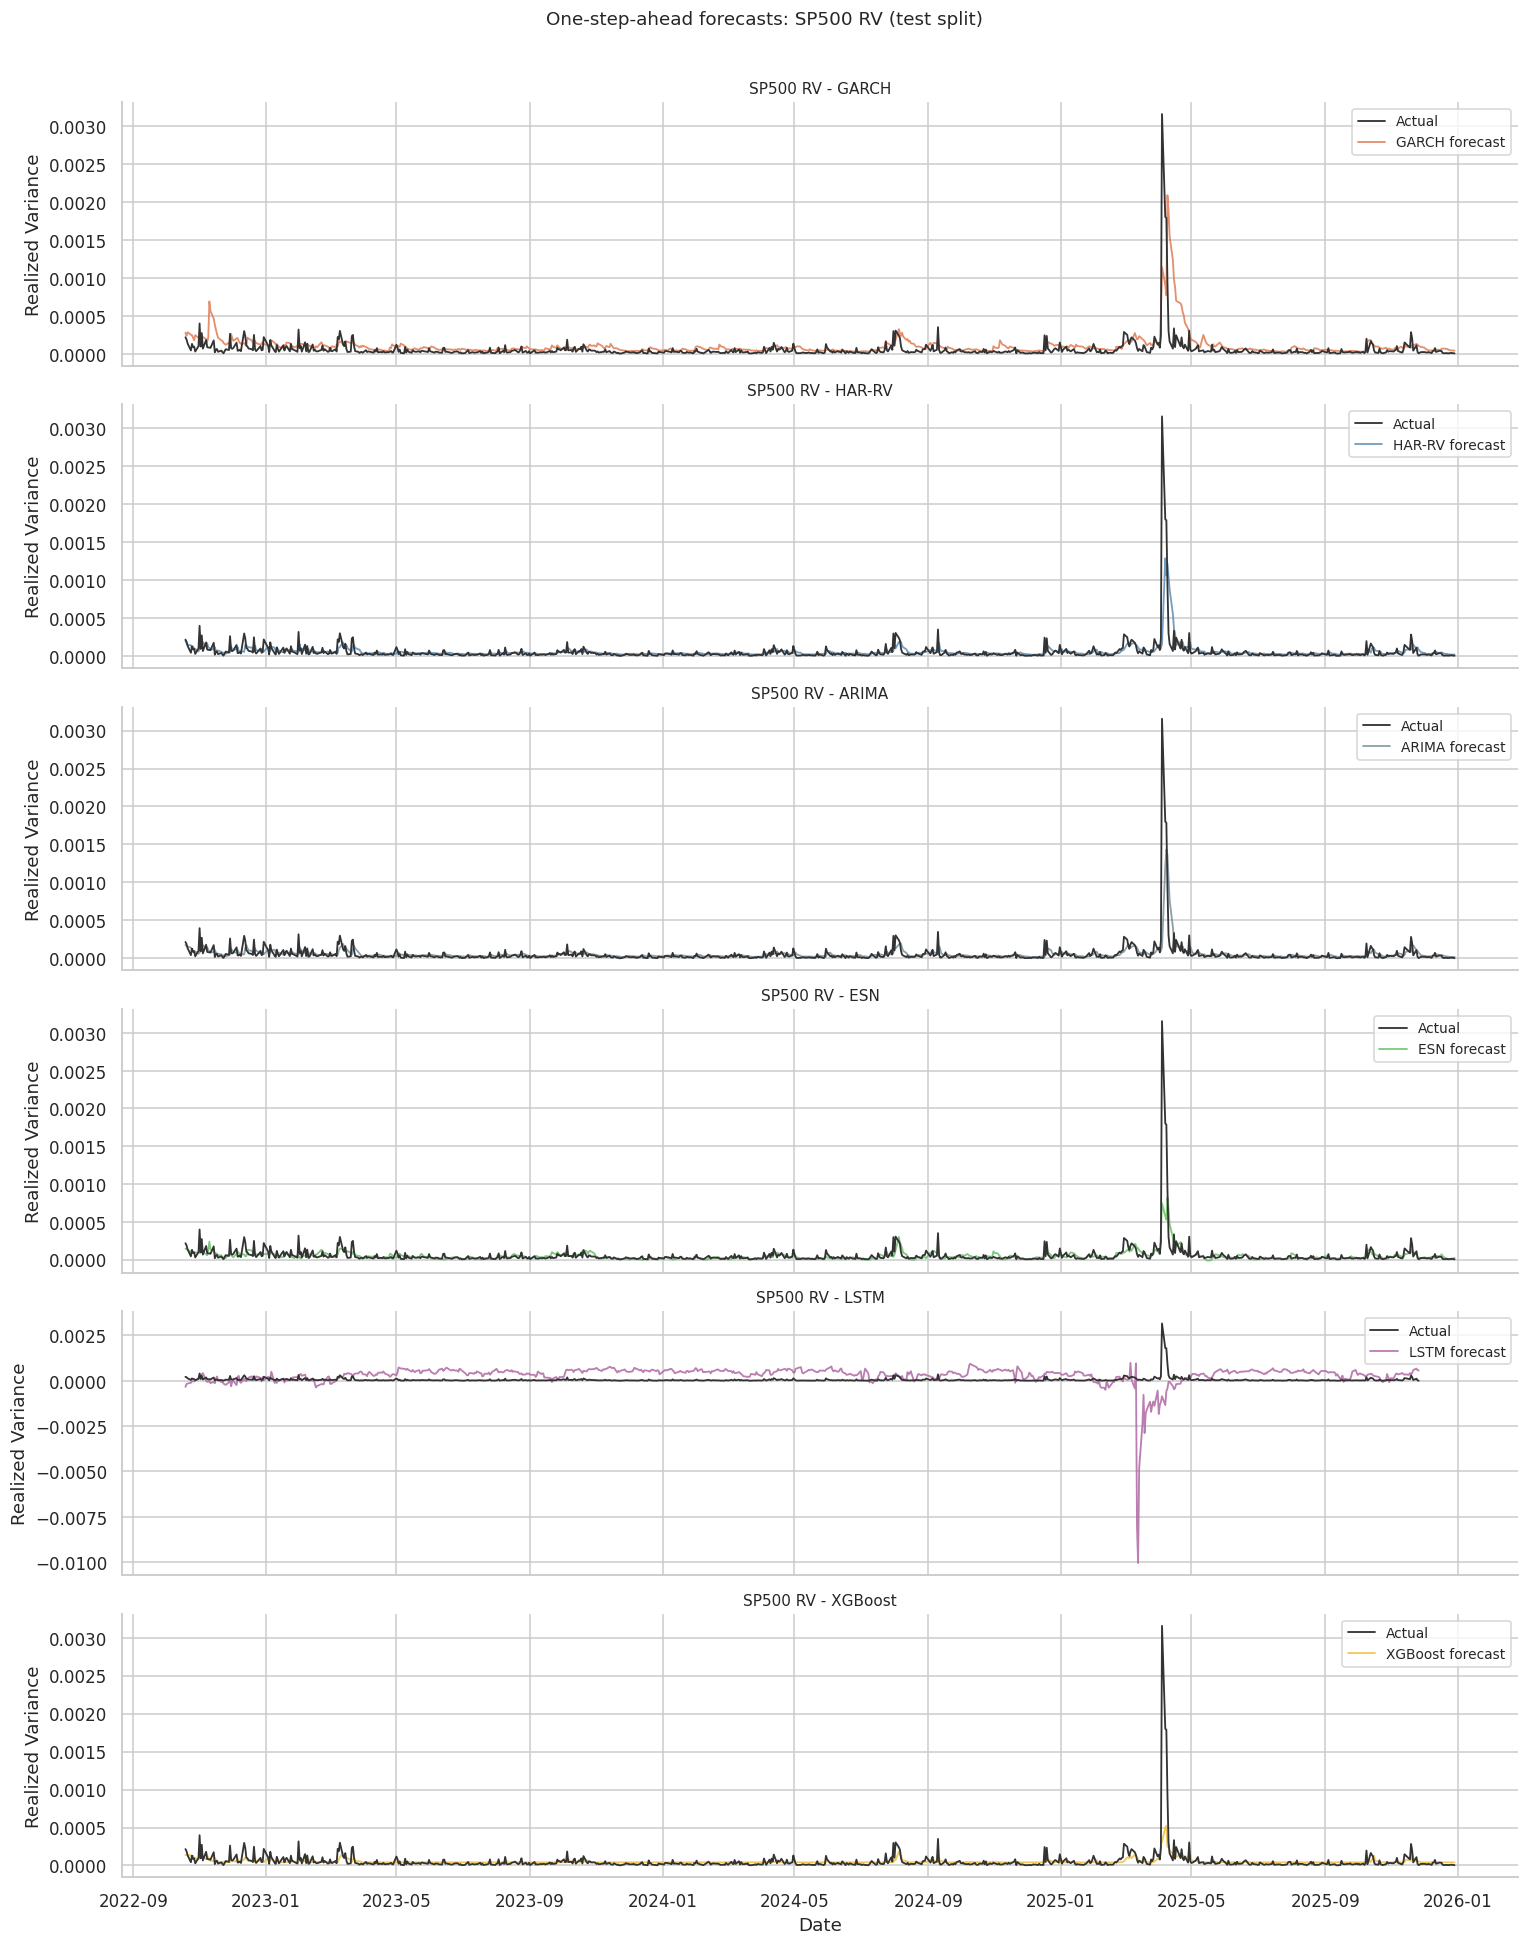

  saved forecasts_vix_level.png


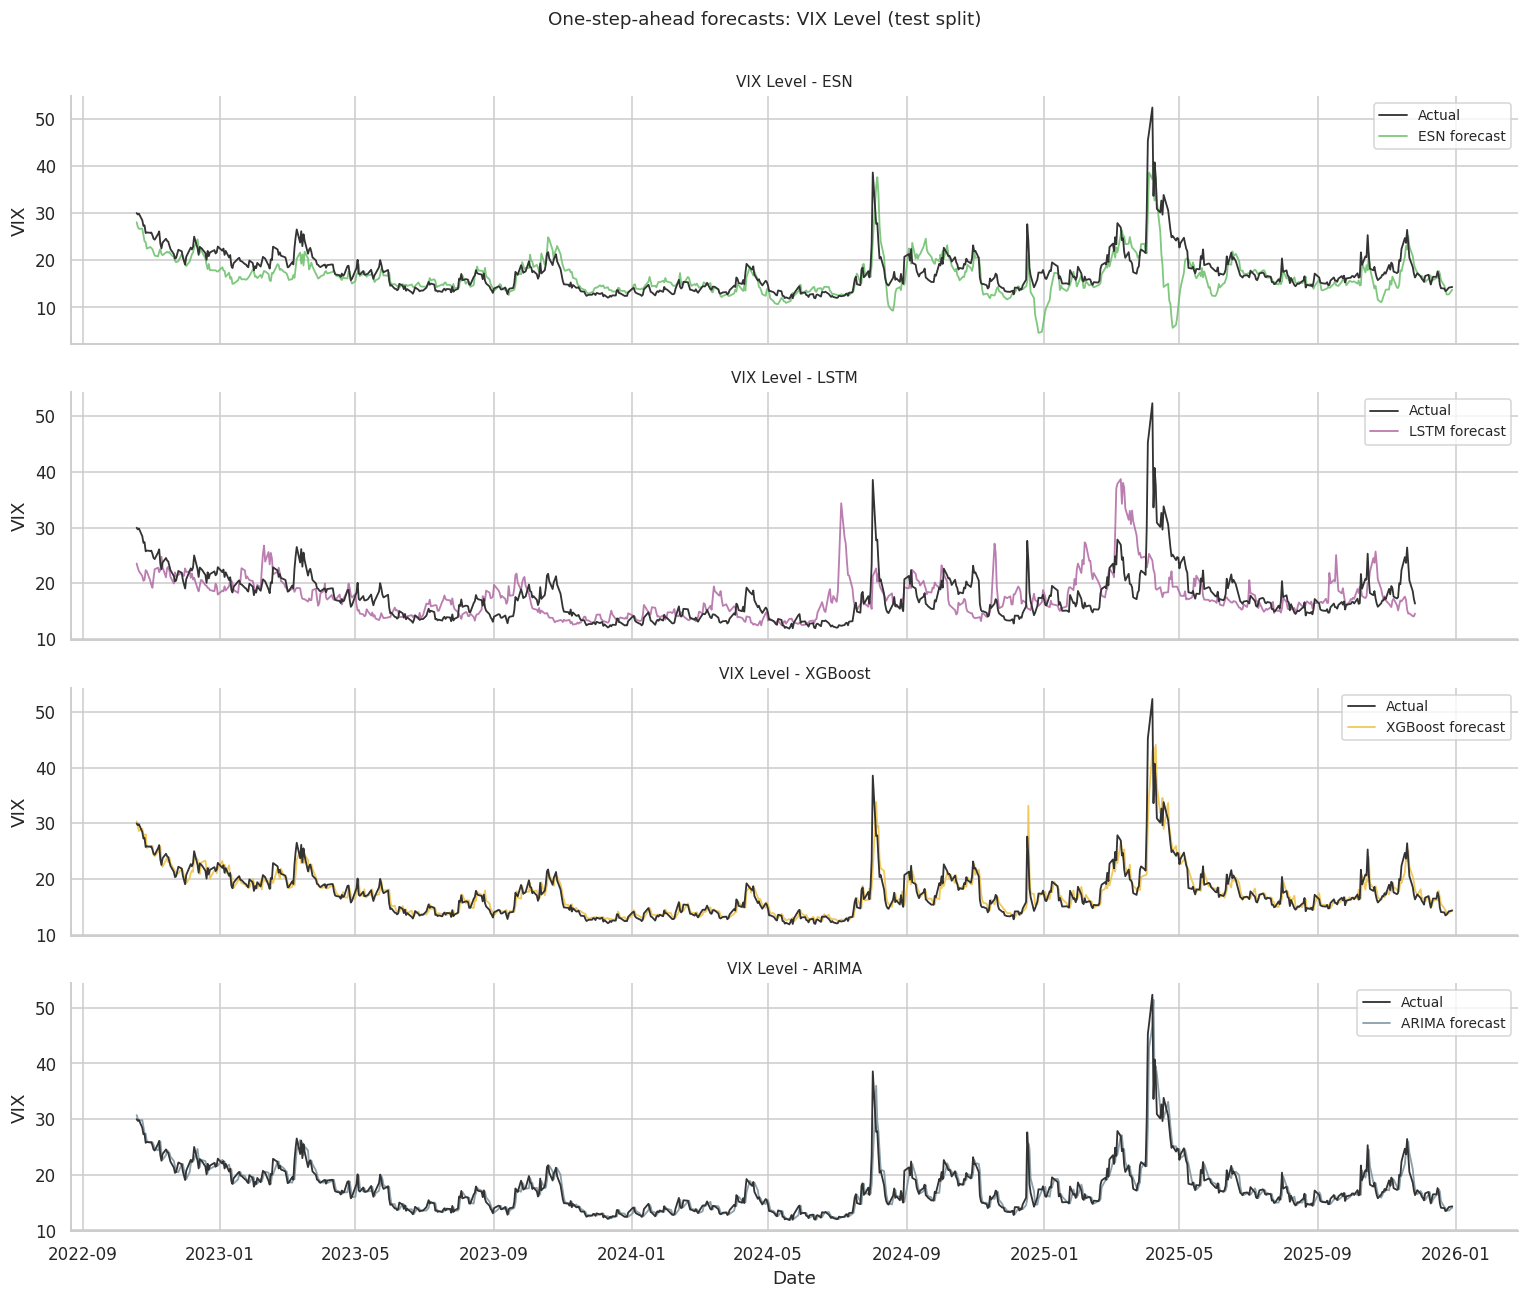

  saved forecasts_mackey_glass.png


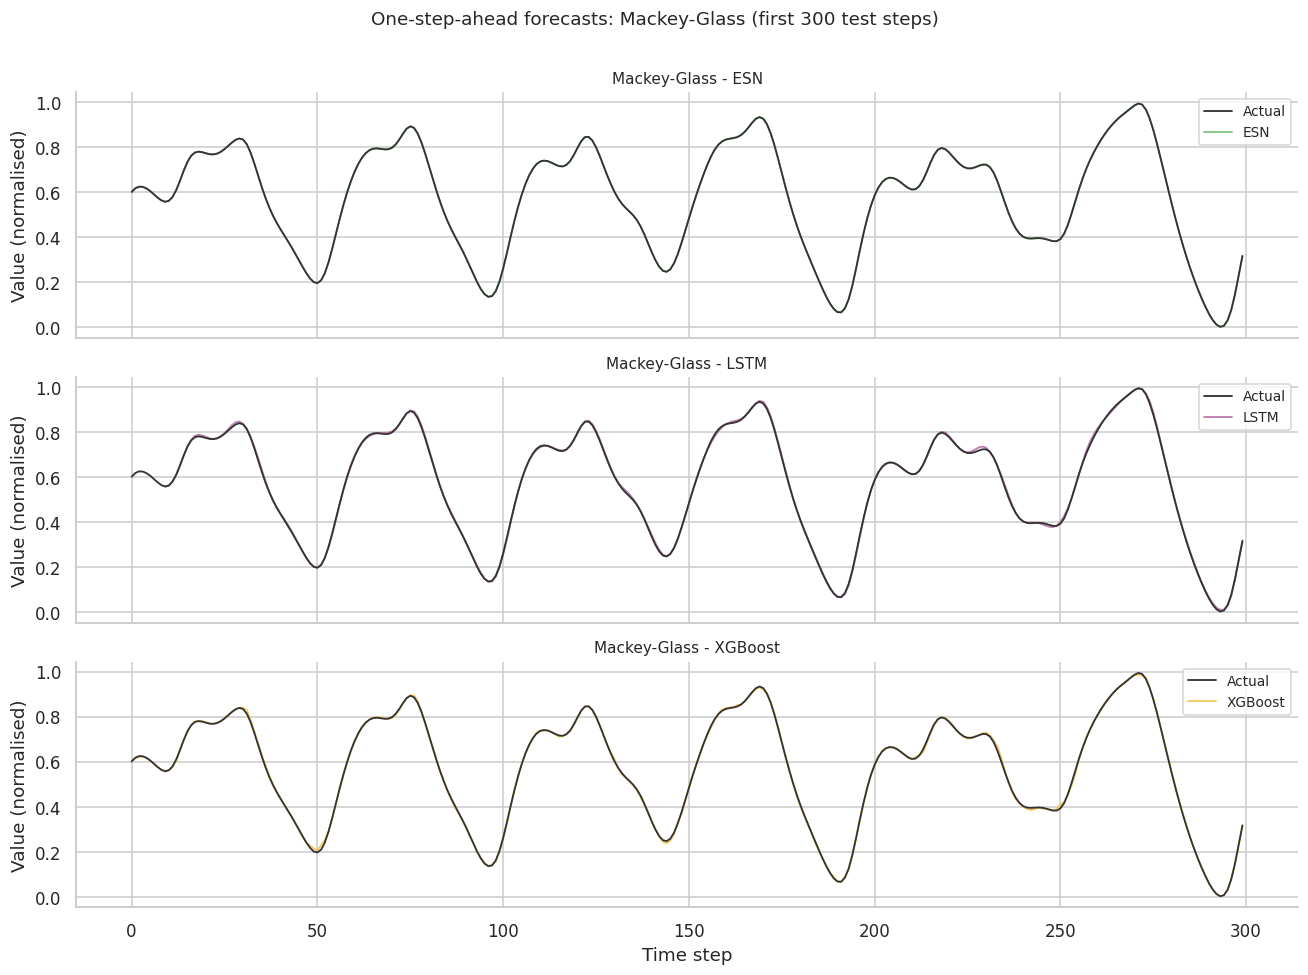

  saved forecasts_lorenz.png


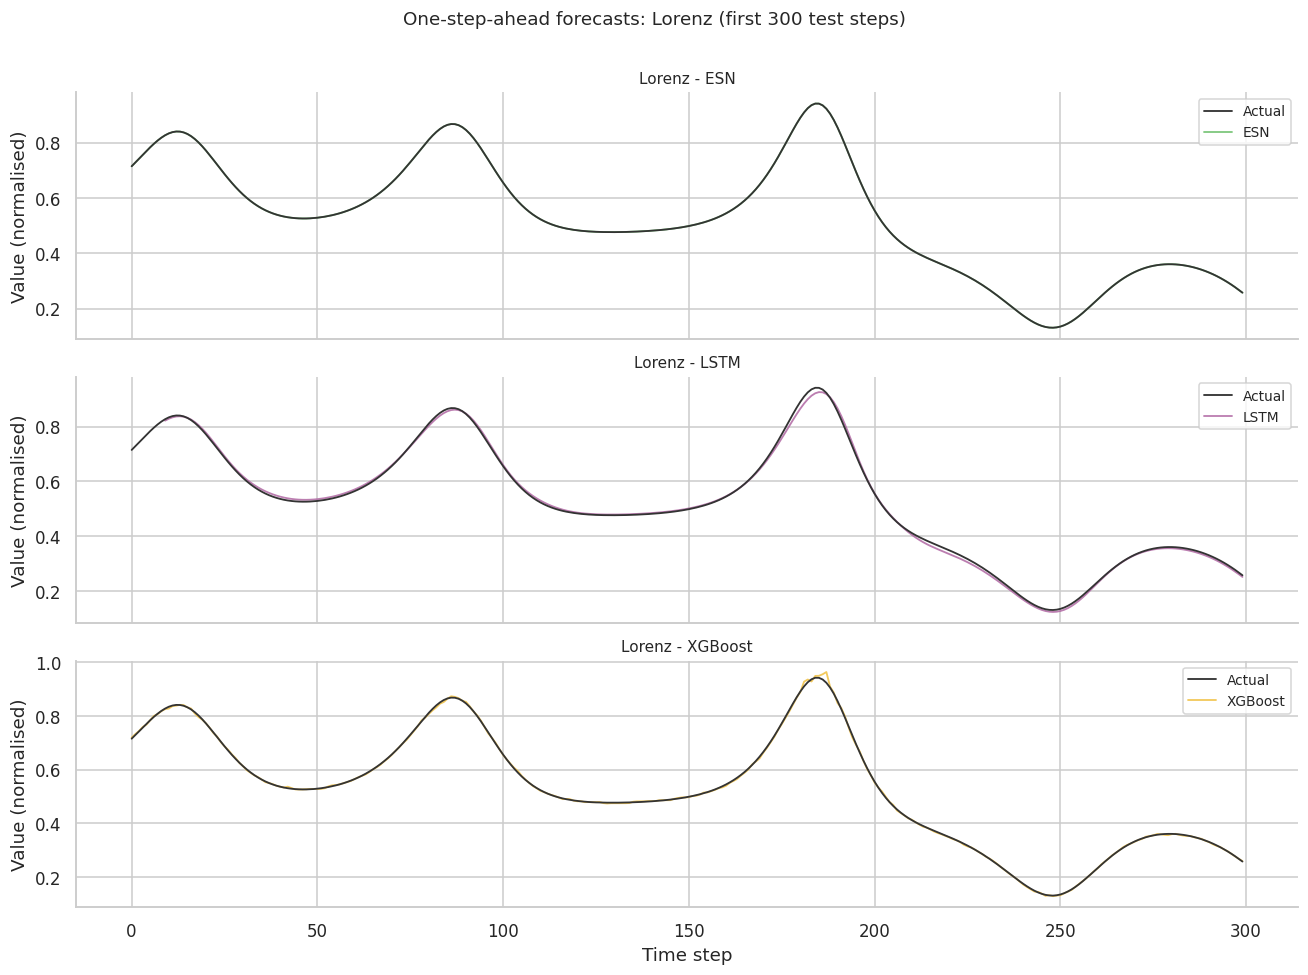

  saved metrics_heatmap.png


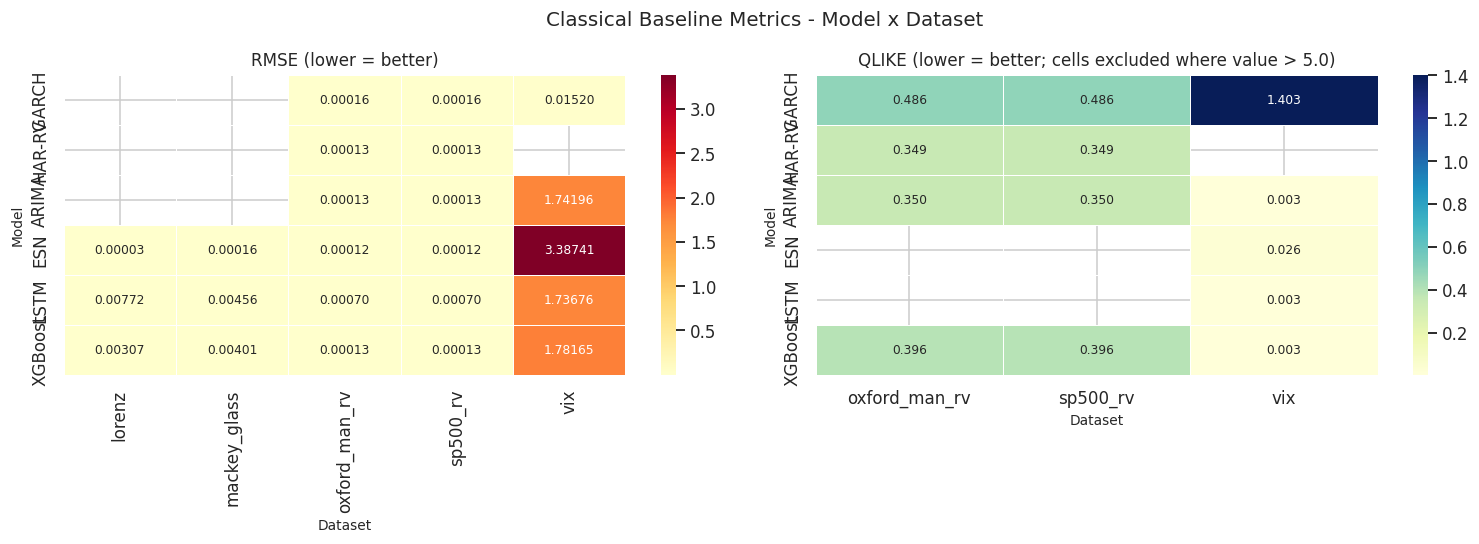

  saved rmse_comparison.png


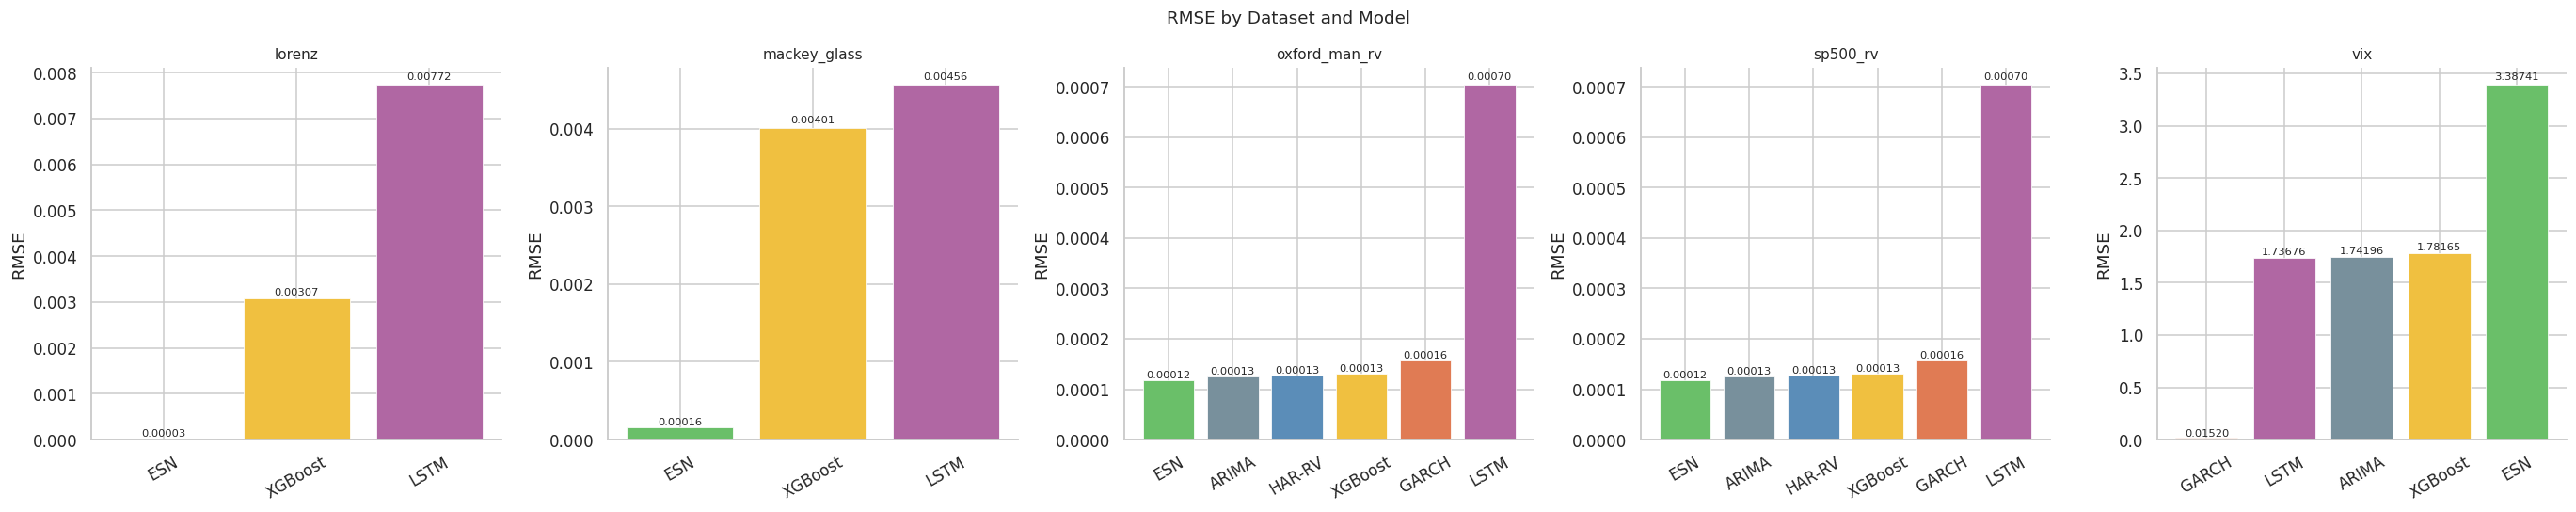

  saved radar_chart.png


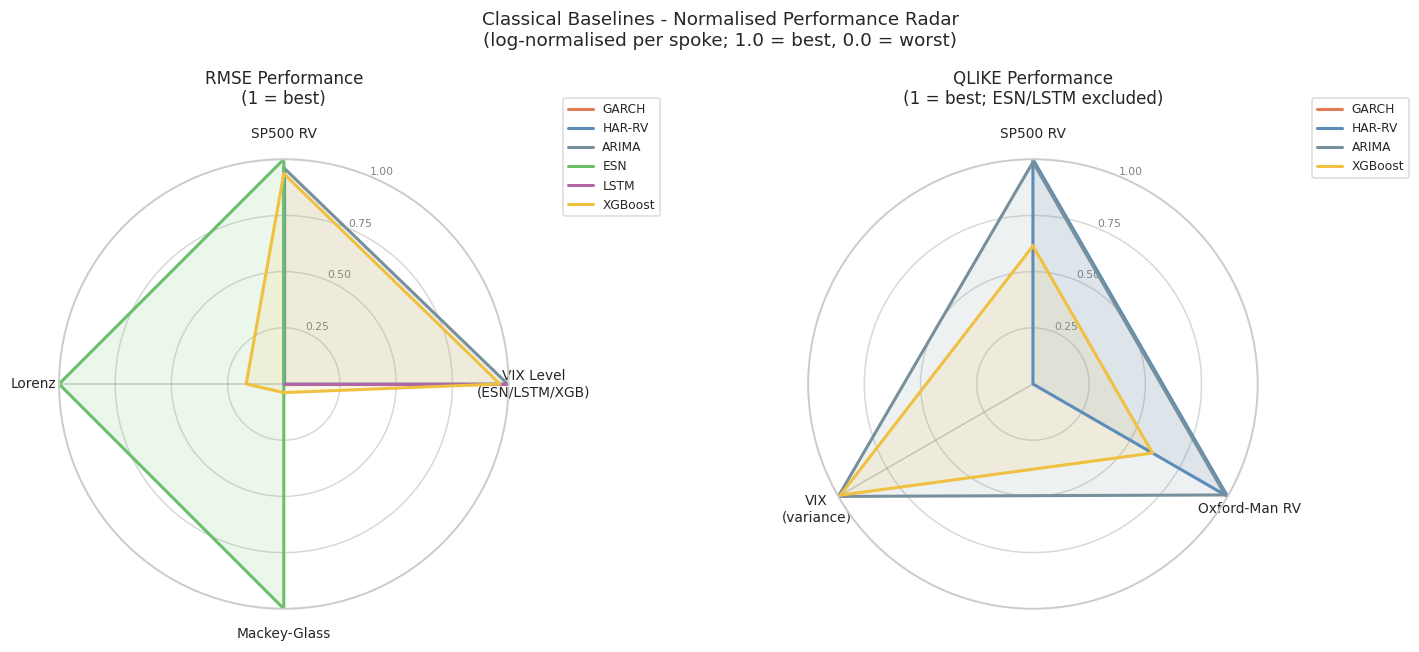

  saved regime_overlay.png


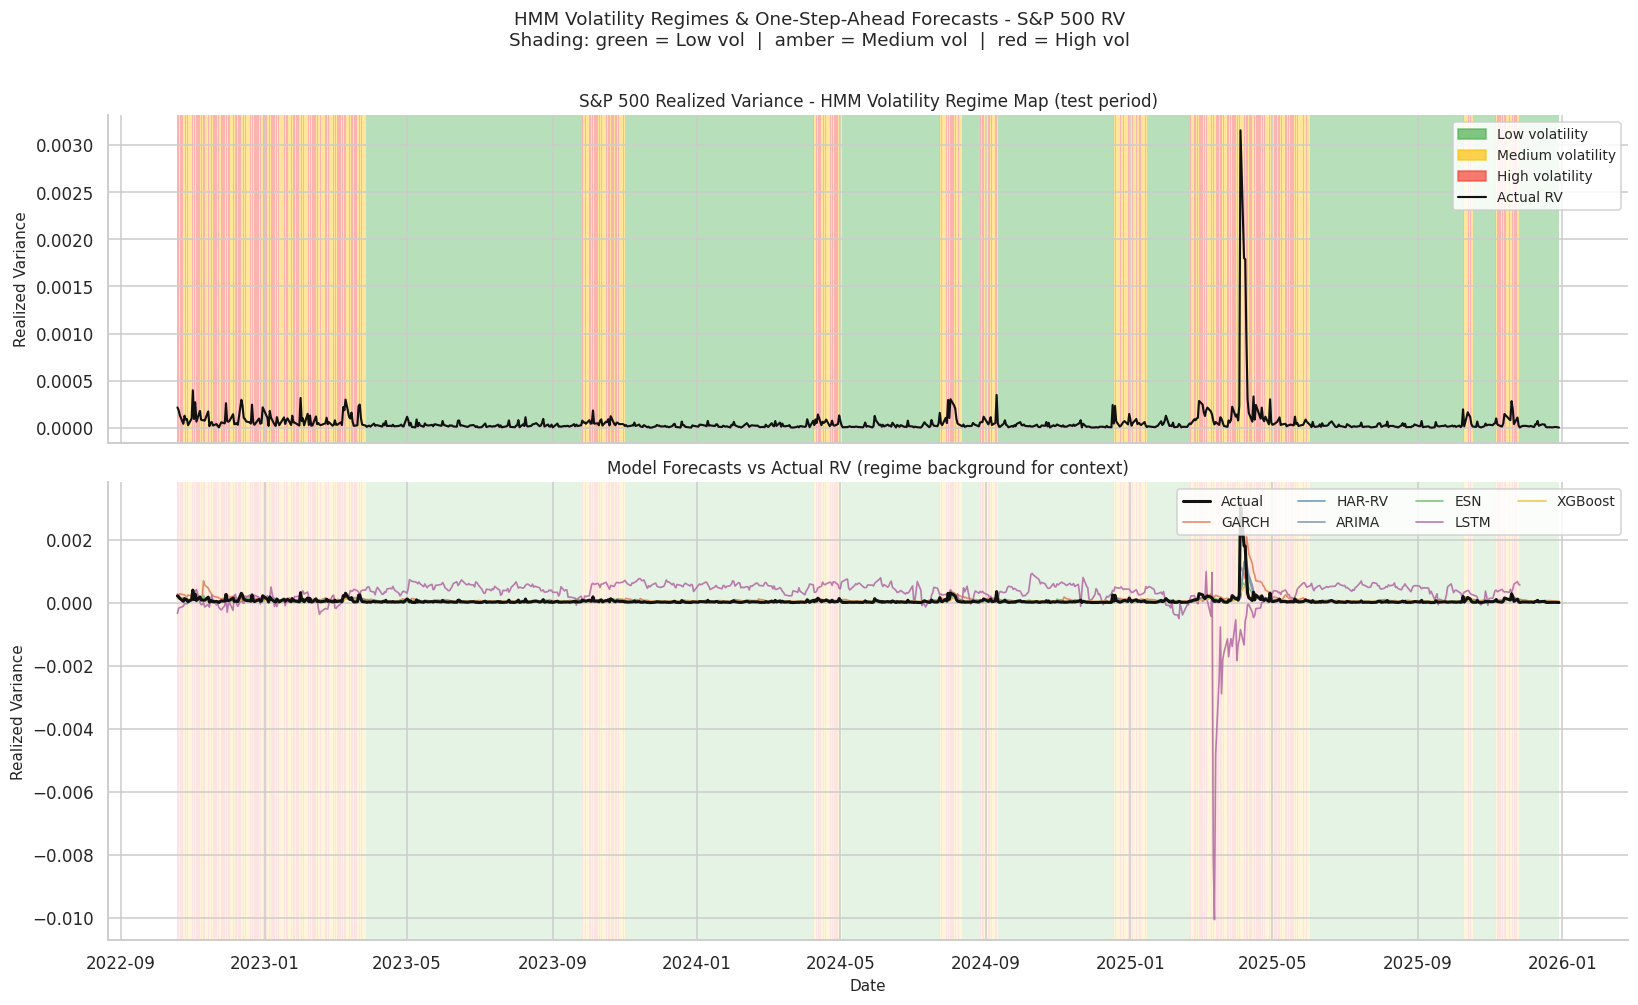

  saved regime_dashboard.png


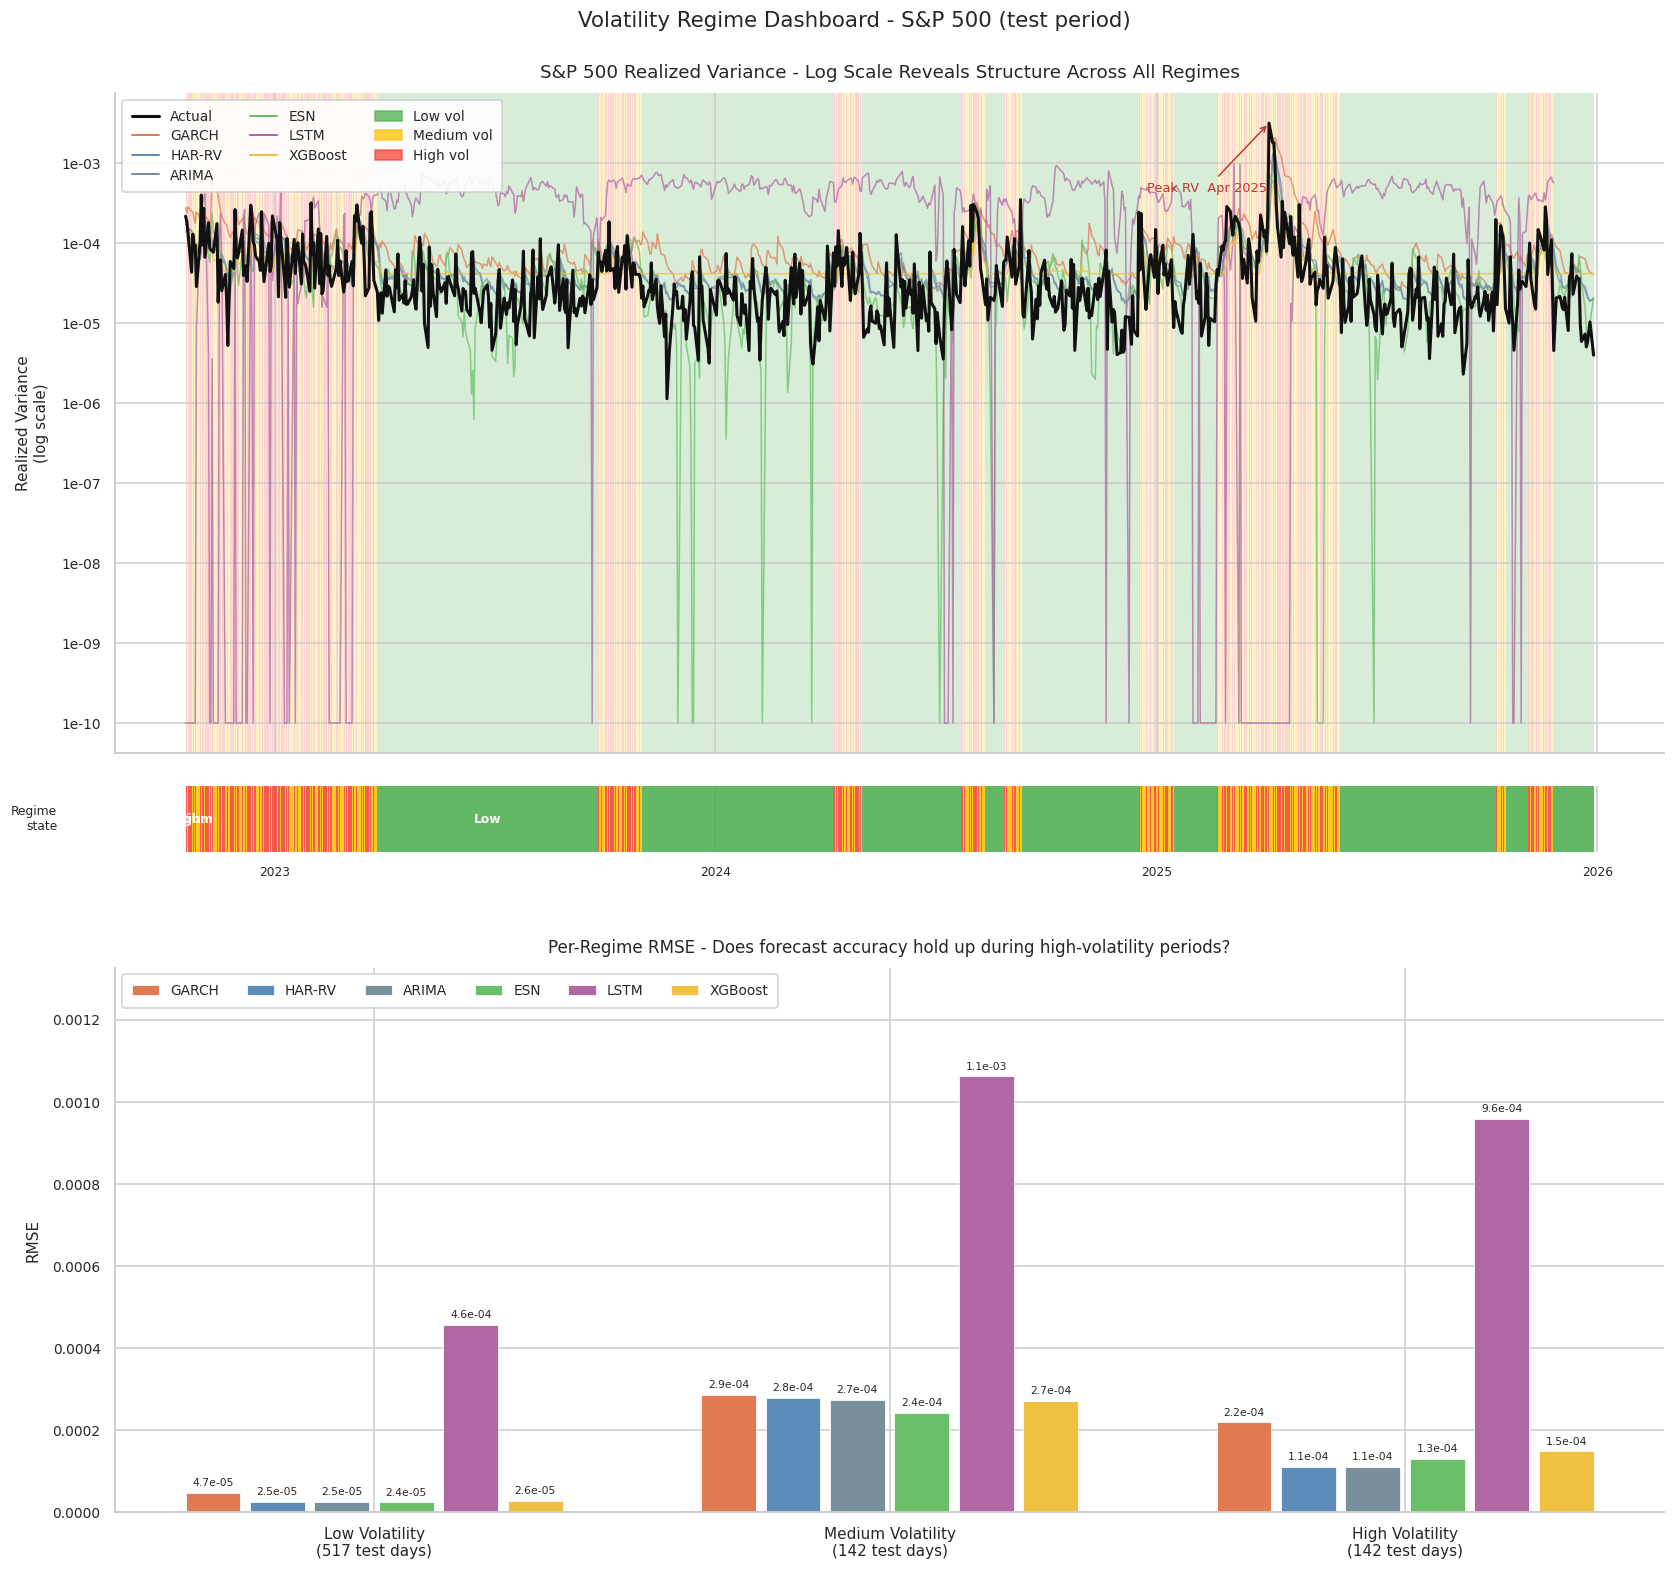

  saved regime_accuracy.png


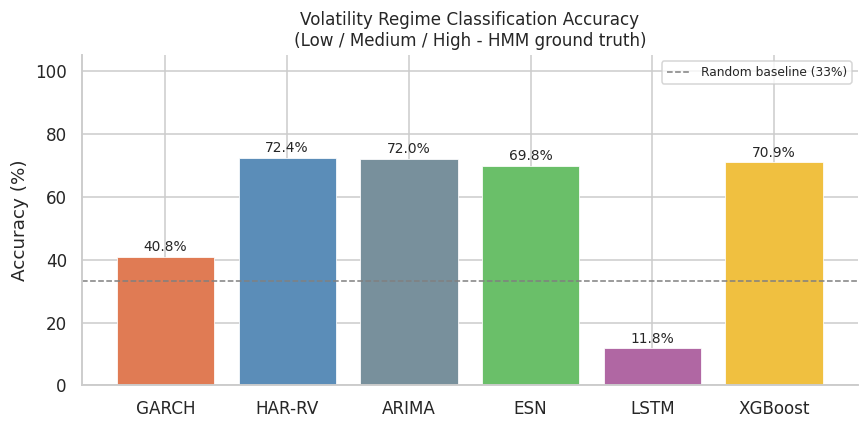

  saved sharpe_comparison.png


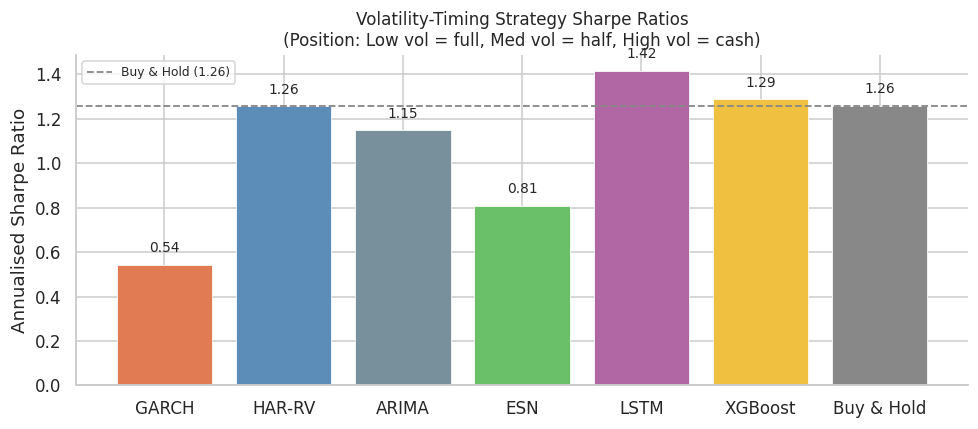

  saved lstm_training_loss.png


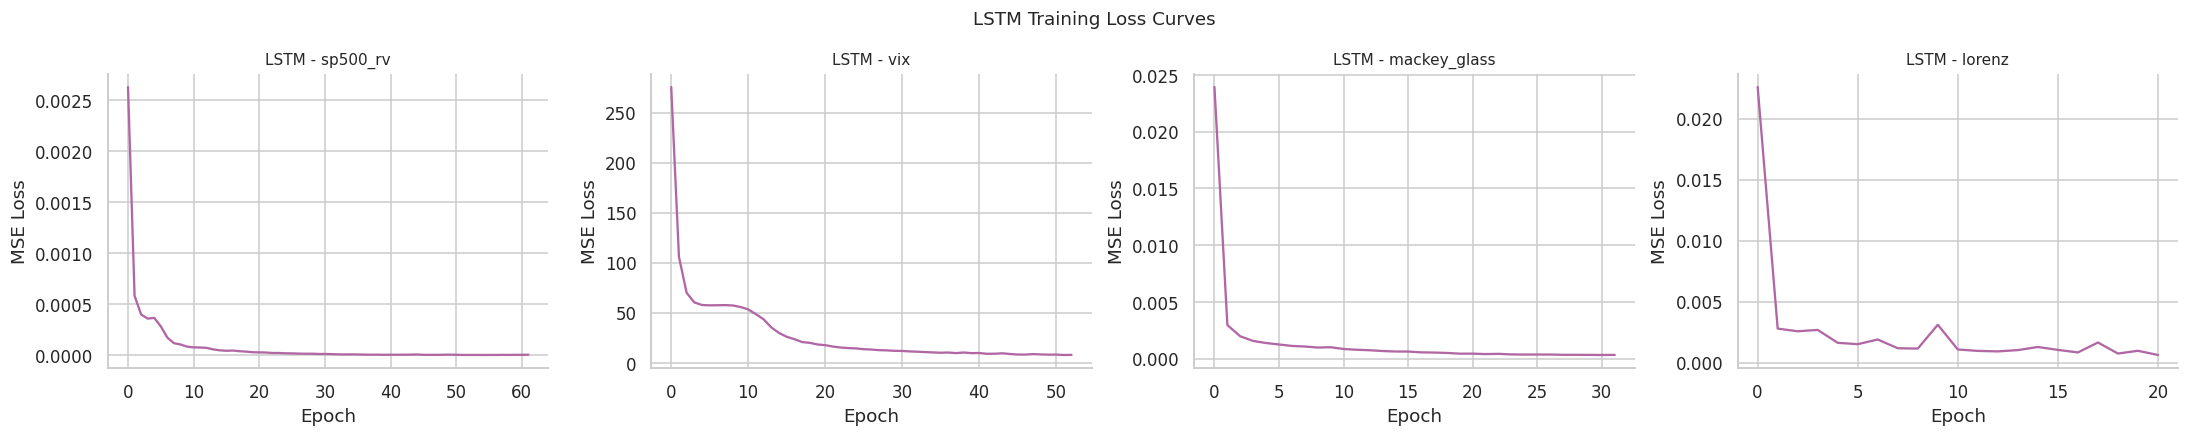

  saved lorenz_attractor.png


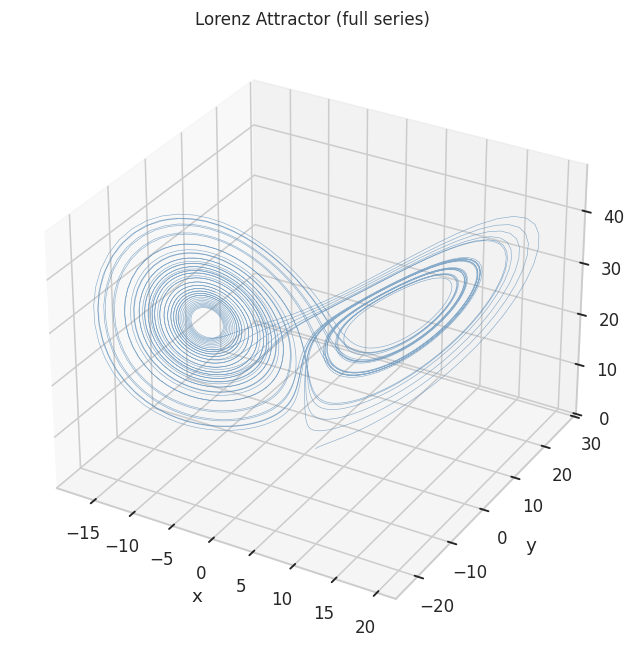

  saved xgboost_importance.png


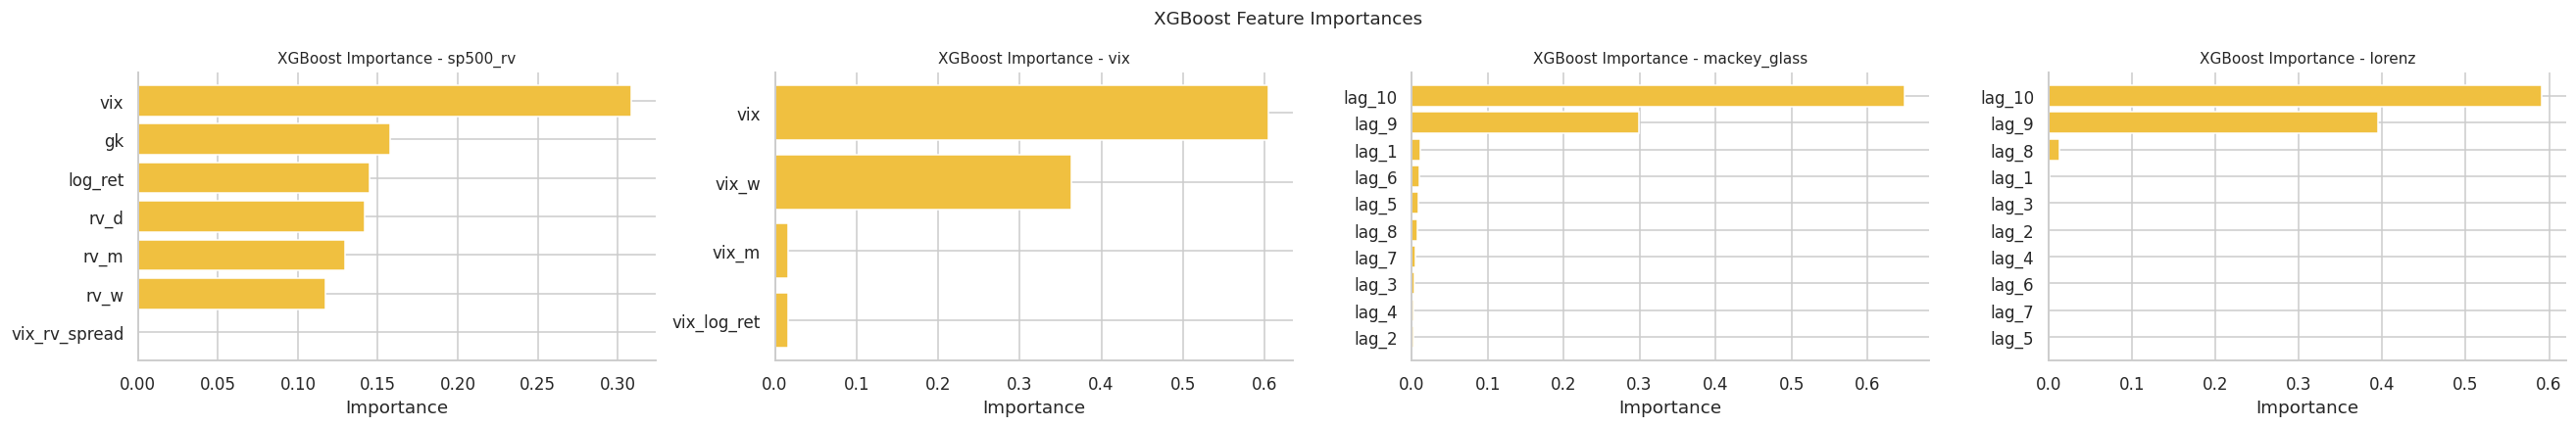


All plots saved to: results/plots


In [20]:
# --- Mirrors utils/plots.py ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

PALETTE = {
    "GARCH":   "#E07B54",
    "HAR-RV":  "#5B8DB8",
    "ESN":     "#6ABF69",
    "LSTM":    "#B067A3",
    "XGBoost": "#F0C040",
    "ARIMA":   "#78909C",
}
MODEL_ORDER = ["GARCH", "HAR-RV", "ARIMA", "ESN", "LSTM", "XGBoost"]

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})


def _save(fig, name, dpi=120):
    out = PLOTS_DIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", dpi=dpi)
    print(f"  saved {out.name}")


# -----------------------------------------------------------------------------
# 1. Financial forecasts (stacked per-model subplots)
# -----------------------------------------------------------------------------
def plot_financial_forecasts(dates, y_true, predictions, dataset_label,
                             ylabel="Realized Variance"):
    n = len(predictions)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, (name, y_pred) in zip(axes, predictions.items()):
        m = min(len(dates), len(y_true), len(y_pred))
        ax.plot(dates[:m], y_true[:m], color="#333333", lw=1.2, label="Actual", zorder=3)
        ax.plot(dates[:m], y_pred[:m], color=PALETTE.get(name, "tab:blue"),
                lw=1.2, alpha=0.85, label=f"{name} forecast")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, loc="upper right")
        ax.set_title(f"{dataset_label} - {name}", fontsize=10)
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"One-step-ahead forecasts: {dataset_label} (test split)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    _save(fig, f"forecasts_{dataset_label.lower().replace(' ', '_')}")
    plt.show()


plot_financial_forecasts(test_dates_fin, y_true_sp500, fin_preds, "SP500 RV")
plot_financial_forecasts(test_dates_vix, y_true_vix_level, vix_preds, "VIX Level",
                         ylabel="VIX")

# -----------------------------------------------------------------------------
# 2. Chaotic forecasts (aligned)
# -----------------------------------------------------------------------------
def plot_chaotic_forecasts(y_true, predictions, dataset_label, n_show=300):
    n_show = min(n_show, len(y_true))
    fig, axes = plt.subplots(len(predictions), 1, figsize=(12, 3 * len(predictions)),
                             sharex=True)
    if len(predictions) == 1:
        axes = [axes]
    for ax, (name, y_pred) in zip(axes, predictions.items()):
        if name == "LSTM":
            offset = seq_skip_c
            p = y_pred[:max(0, n_show - offset)]
            ax.plot(y_true[:n_show], color="#333333", lw=1.2, label="Actual", zorder=3)
            ax.plot(range(offset, offset + len(p)), p, color=PALETTE.get(name, "tab:blue"),
                    lw=1.2, alpha=0.85, label=name)
        else:
            ax.plot(y_true[:n_show], color="#333333", lw=1.2, label="Actual", zorder=3)
            ax.plot(y_pred[:n_show], color=PALETTE.get(name, "tab:blue"),
                    lw=1.2, alpha=0.85, label=name)
        ax.set_ylabel("Value (normalised)")
        ax.legend(fontsize=9, loc="upper right")
        ax.set_title(f"{dataset_label} - {name}", fontsize=10)
    axes[-1].set_xlabel("Time step")
    fig.suptitle(f"One-step-ahead forecasts: {dataset_label} (first {n_show} test steps)",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    _save(fig, f"forecasts_{dataset_label.lower().replace('-', '_').replace(' ', '_')}")
    plt.show()


plot_chaotic_forecasts(mg_split["y_test"], mg_preds, "Mackey-Glass")
plot_chaotic_forecasts(lor_split["y_test"], lor_preds, "Lorenz")

# -----------------------------------------------------------------------------
# 3. Metrics heatmap (RMSE + QLIKE, with QLIKE cap)
# -----------------------------------------------------------------------------
def plot_metrics_heatmap(metrics_df, qlike_cap=5.0):
    pivot_rmse = metrics_df.pivot(index="model", columns="dataset", values="rmse")
    pivot_rmse = pivot_rmse.reindex([m for m in MODEL_ORDER if m in pivot_rmse.index])

    has_qlike = "qlike" in metrics_df.columns and metrics_df["qlike"].notna().any()
    pivot_qlike = None
    if has_qlike:
        ql = metrics_df[metrics_df["qlike"].notna()].copy()
        rel = ql[ql["qlike"] <= qlike_cap]
        if not rel.empty:
            pivot_qlike = rel.pivot(index="model", columns="dataset", values="qlike")
            pivot_qlike = pivot_qlike.reindex(
                [m for m in MODEL_ORDER if m in pivot_qlike.index])
        else:
            has_qlike = False

    if has_qlike:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

    def _h(data, ax, title, fmt=".5f", cmap="YlOrRd"):
        sns.heatmap(data.astype(float), annot=True, fmt=fmt, cmap=cmap,
                    mask=data.isna(), ax=ax, linewidths=0.5, annot_kws={"size": 8})
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Dataset", fontsize=9); ax.set_ylabel("Model", fontsize=9)

    _h(pivot_rmse, ax1, "RMSE (lower = better)")
    if has_qlike:
        _h(pivot_qlike, ax2,
           f"QLIKE (lower = better; cells excluded where value > {qlike_cap})",
           fmt=".3f", cmap="YlGnBu")
    fig.suptitle("Classical Baseline Metrics - Model x Dataset", fontsize=13)
    fig.tight_layout()
    _save(fig, "metrics_heatmap")
    plt.show()


plot_metrics_heatmap(metrics_df)

# -----------------------------------------------------------------------------
# 4. RMSE comparison bars per dataset
# -----------------------------------------------------------------------------
def plot_rmse_bars(metrics_df):
    datasets = metrics_df["dataset"].unique()
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, ds in zip(axes, datasets):
        sub = metrics_df[metrics_df["dataset"] == ds].sort_values("rmse")
        colors = [PALETTE.get(m, "grey") for m in sub["model"]]
        bars = ax.bar(sub["model"], sub["rmse"], color=colors,
                      edgecolor="white", linewidth=0.5)
        ax.set_title(ds, fontsize=10); ax.set_ylabel("RMSE")
        ax.tick_params(axis="x", rotation=30)
        for b, v in zip(bars, sub["rmse"]):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
                    f"{v:.5f}", ha="center", va="bottom", fontsize=7.5)
    fig.suptitle("RMSE by Dataset and Model", fontsize=12)
    fig.tight_layout()
    _save(fig, "rmse_comparison")
    plt.show()


plot_rmse_bars(metrics_df)

# -----------------------------------------------------------------------------
# 5. Radar - RMSE panel + QLIKE panel (log-normalised per spoke)
# -----------------------------------------------------------------------------
def _log_normalize(values):
    v = np.array(values, dtype=float)
    lv = np.log(v + 1e-30)
    lo, hi = np.nanmin(lv), np.nanmax(lv)
    if hi == lo:
        return np.ones_like(v)
    return 1.0 - (lv - lo) / (hi - lo)


def plot_radar_chart(metrics_df):
    rmse_spokes = ["sp500_rv", "vix", "mackey_glass", "lorenz"]
    vix_level_models = {"ESN", "LSTM", "XGBoost", "ARIMA"}
    rmse_df = metrics_df.pivot(index="model", columns="dataset", values="rmse")
    rmse_norm = {m: [] for m in MODEL_ORDER}
    for ds in rmse_spokes:
        vals = []
        for m in MODEL_ORDER:
            if m not in rmse_df.index or ds not in rmse_df.columns:
                vals.append(np.nan)
            elif np.isnan(rmse_df.loc[m, ds]):
                vals.append(np.nan)
            elif ds == "vix" and m not in vix_level_models:
                vals.append(np.nan)
            else:
                vals.append(rmse_df.loc[m, ds])
        vals = np.array(vals)
        mask = ~np.isnan(vals)
        if mask.sum() < 2:
            normed = np.where(mask, 1.0, 0.0)
        else:
            nv = _log_normalize(vals[mask])
            normed = np.zeros(len(vals)); normed[mask] = nv
        for j, m in enumerate(MODEL_ORDER):
            rmse_norm[m].append(normed[j])

    qlike_models = ["GARCH", "HAR-RV", "ARIMA", "XGBoost"]
    qlike_spokes = ["sp500_rv", "oxford_man_rv", "vix"]
    qlike_df = metrics_df.pivot(index="model", columns="dataset", values="qlike")
    qlike_norm = {m: [] for m in qlike_models}
    for ds in qlike_spokes:
        vals = []
        for m in qlike_models:
            if m not in qlike_df.index or ds not in qlike_df.columns:
                vals.append(np.nan)
            elif np.isnan(qlike_df.loc[m, ds]):
                vals.append(np.nan)
            else:
                vals.append(qlike_df.loc[m, ds])
        vals = np.array(vals)
        mask = ~np.isnan(vals)
        if mask.sum() < 2:
            normed = np.where(mask, 1.0, 0.0)
        else:
            nv = _log_normalize(vals[mask])
            normed = np.zeros(len(vals)); normed[mask] = nv
        for j, m in enumerate(qlike_models):
            qlike_norm[m].append(normed[j])

    fig, (ax_r, ax_q) = plt.subplots(1, 2, figsize=(14, 6),
                                     subplot_kw={"projection": "polar"})

    def _draw(ax, labels, scores, title, models):
        nn = len(labels)
        ang = np.linspace(0, 2 * np.pi, nn, endpoint=False).tolist()
        ang += ang[:1]
        ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
        ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylim(0, 1.0); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="grey")
        ax.yaxis.grid(True, color="grey", alpha=0.3)
        ax.xaxis.grid(True, color="grey", alpha=0.4)
        for m in models:
            s = scores[m] + scores[m][:1]
            c = PALETTE.get(m, "grey")
            ax.plot(ang, s, color=c, lw=2, label=m)
            ax.fill(ang, s, color=c, alpha=0.12)
        ax.set_title(title, fontsize=11, pad=15)
        ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
                  fontsize=8, framealpha=0.7)

    _draw(ax_r, ["SP500 RV", "VIX Level\n(ESN/LSTM/XGB)", "Mackey-Glass", "Lorenz"],
          rmse_norm, "RMSE Performance\n(1 = best)", MODEL_ORDER)
    _draw(ax_q, ["SP500 RV", "Oxford-Man RV", "VIX\n(variance)"],
          qlike_norm, "QLIKE Performance\n(1 = best; ESN/LSTM excluded)", qlike_models)
    fig.suptitle("Classical Baselines - Normalised Performance Radar\n"
                 "(log-normalised per spoke; 1.0 = best, 0.0 = worst)", fontsize=12)
    fig.tight_layout()
    _save(fig, "radar_chart")
    plt.show()


plot_radar_chart(metrics_df)

# -----------------------------------------------------------------------------
# 6. Regime overlay - 2 panels
# -----------------------------------------------------------------------------
def plot_regime_overlay(dates, rv_true, regimes, predictions):
    def _shade(ax, alpha):
        prev_r, start_i = int(regimes[0]), 0
        for i in range(1, len(regimes) + 1):
            cur_r = int(regimes[i]) if i < len(regimes) else -1
            if cur_r != prev_r:
                ax.axvspan(dates[start_i], dates[min(i, len(dates) - 1)],
                           alpha=alpha, color=REGIME_COLORS[prev_r], lw=0, zorder=0)
                prev_r, start_i = cur_r, i

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 1.4]})
    _shade(ax1, alpha=0.40)
    ax1.plot(dates, rv_true, color="#111111", lw=1.4, label="Realized Variance", zorder=3)
    ax1.set_ylabel("Realized Variance", fontsize=10)
    ax1.set_title("S&P 500 Realized Variance - HMM Volatility Regime Map (test period)",
                  fontsize=11)
    patches = [mpatches.Patch(color=REGIME_COLORS[i], alpha=0.7,
                              label=f"{REGIME_NAMES[i]} volatility") for i in range(3)]
    ax1.legend(handles=patches +
               [plt.Line2D([0], [0], color="#111111", lw=1.4, label="Actual RV")],
               fontsize=9, loc="upper right", framealpha=0.85)

    _shade(ax2, alpha=0.15)
    ax2.plot(dates, rv_true, color="#111111", lw=2.0, label="Actual", zorder=5)
    for name, y_pred in predictions.items():
        nn = min(len(dates), len(rv_true), len(y_pred))
        ax2.plot(dates[:nn], y_pred[:nn], color=PALETTE.get(name, "grey"),
                 lw=1.1, alpha=0.85, label=name, zorder=4)
    ax2.set_ylabel("Realized Variance", fontsize=10); ax2.set_xlabel("Date", fontsize=10)
    ax2.set_title("Model Forecasts vs Actual RV (regime background for context)", fontsize=11)
    ax2.legend(fontsize=9, ncol=4, loc="upper right", framealpha=0.85)
    fig.suptitle("HMM Volatility Regimes & One-Step-Ahead Forecasts - S&P 500 RV\n"
                 "Shading: green = Low vol  |  amber = Medium vol  |  red = High vol",
                 fontsize=12, y=1.01)
    fig.tight_layout()
    _save(fig, "regime_overlay")
    plt.show()


plot_regime_overlay(test_dates_fin, y_true_sp500, true_regimes_test, fin_preds)

# -----------------------------------------------------------------------------
# 7. Regime dashboard - 3-row publication layout
# -----------------------------------------------------------------------------
def plot_regime_dashboard(dates, rv_true, regimes, predictions):
    fig = plt.figure(figsize=(16, 15))
    ax_ts    = fig.add_axes([0.08, 0.52, 0.88, 0.40])
    ax_strip = fig.add_axes([0.08, 0.46, 0.88, 0.04], sharex=ax_ts)
    ax_bar   = fig.add_axes([0.08, 0.06, 0.88, 0.33])

    def _shade(ax, alpha):
        prev_r, start_i = int(regimes[0]), 0
        for i in range(1, len(regimes) + 1):
            cur_r = int(regimes[i]) if i < len(regimes) else -1
            if cur_r != prev_r:
                ax.axvspan(dates[start_i], dates[min(i, len(dates) - 1)],
                           alpha=alpha, color=REGIME_COLORS[prev_r], lw=0, zorder=0)
                prev_r, start_i = cur_r, i

    _shade(ax_ts, alpha=0.22)
    for name, y_pred in predictions.items():
        nn = min(len(dates), len(rv_true), len(y_pred))
        ax_ts.plot(dates[:nn], np.maximum(y_pred[:nn], 1e-10),
                   color=PALETTE.get(name, "grey"), lw=1.0, alpha=0.75,
                   label=name, zorder=3)
    ax_ts.plot(dates, rv_true, color="#111111", lw=2.0, label="Actual", zorder=5)
    ax_ts.set_yscale("log")
    ax_ts.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0e}"))
    ax_ts.set_ylabel("Realized Variance\n(log scale)", fontsize=10, labelpad=8)
    ax_ts.set_title("S&P 500 Realized Variance - Log Scale Reveals Structure Across All Regimes",
                    fontsize=12, pad=10)
    peak_i = int(np.argmax(rv_true))
    ax_ts.annotate(f"Peak RV  {dates[peak_i].strftime('%b %Y')}",
                   xy=(dates[peak_i], rv_true[peak_i]),
                   xytext=(-80, -45), textcoords="offset points",
                   fontsize=8.5, color="#c0392b",
                   arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.0))
    patches = [mpatches.Patch(color=REGIME_COLORS[i], alpha=0.75,
                              label=f"{REGIME_NAMES[i]} vol") for i in range(3)]
    model_lines = [plt.Line2D([0], [0], color="#111111", lw=2.0, label="Actual")] + [
        plt.Line2D([0], [0], color=PALETTE.get(n, "grey"), lw=1.3, label=n)
        for n in predictions]
    ax_ts.legend(handles=model_lines + patches, fontsize=9, ncol=3, loc="upper left",
                 framealpha=0.9, borderpad=0.7, labelspacing=0.4)
    plt.setp(ax_ts.get_xticklabels(), visible=False)
    ax_ts.tick_params(axis="y", labelsize=9)

    prev_r, start_i = int(regimes[0]), 0
    for i in range(1, len(regimes) + 1):
        cur_r = int(regimes[i]) if i < len(regimes) else -1
        if cur_r != prev_r:
            ax_strip.axvspan(dates[start_i], dates[min(i, len(dates) - 1)],
                             alpha=0.88, color=REGIME_COLORS[prev_r], lw=0)
            prev_r, start_i = cur_r, i
    ax_strip.set_yticks([])
    ax_strip.set_ylabel("Regime\nstate", fontsize=8, rotation=0,
                        labelpad=38, va="center", ha="right")
    for spine in ax_strip.spines.values():
        spine.set_visible(False)
    for r_idx in range(3):
        pos = np.where(regimes == r_idx)[0]
        if len(pos) == 0:
            continue
        runs, run_start = [], pos[0]
        for k in range(1, len(pos) + 1):
            if k == len(pos) or pos[k] != pos[k - 1] + 1:
                runs.append((run_start, pos[k - 1]))
                if k < len(pos):
                    run_start = pos[k]
        longest = max(runs, key=lambda r: r[1] - r[0])
        mid_idx = (longest[0] + longest[1]) // 2
        ax_strip.text(dates[mid_idx], 0.5, REGIME_NAMES[r_idx],
                      ha="center", va="center", fontsize=8, fontweight="bold",
                      color="white", transform=ax_strip.get_xaxis_transform())
    ax_strip.xaxis.set_major_locator(mdates.YearLocator())
    ax_strip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_strip.tick_params(axis="x", labelsize=8, pad=3)

    model_names = list(predictions.keys())
    n_models = len(model_names)
    group_w = 0.75; bar_w = group_w / n_models
    x_base = np.arange(3)
    all_rmse = {}
    for name in model_names:
        y_pred = predictions[name]
        nn = min(len(rv_true), len(y_pred))
        vals = []
        for r_idx in range(3):
            mask = regimes[:nn] == r_idx
            v = float(np.sqrt(np.mean((rv_true[:nn][mask] - y_pred[:nn][mask]) ** 2))) \
                if mask.sum() > 0 else 0.0
            vals.append(v)
        all_rmse[name] = vals
    max_rmse = max(v for vs in all_rmse.values() for v in vs)

    for j, name in enumerate(model_names):
        rpr = all_rmse[name]
        x_pos = x_base + (j - n_models / 2 + 0.5) * bar_w
        bars = ax_bar.bar(x_pos, rpr, width=bar_w * 0.85,
                          color=PALETTE.get(name, "grey"), label=name,
                          edgecolor="white", linewidth=0.5)
        for b, v in zip(bars, rpr):
            if v > 0:
                ax_bar.text(b.get_x() + b.get_width() / 2,
                            b.get_height() + max_rmse * 0.012,
                            f"{v:.1e}", ha="center", va="bottom", fontsize=7)
    ax_bar.set_xticks(x_base)
    ax_bar.set_xticklabels(
        [f"{REGIME_NAMES[i]} Volatility\n({int((regimes == i).sum())} test days)"
         for i in range(3)], fontsize=10)
    ax_bar.set_ylabel("RMSE", fontsize=10, labelpad=8)
    ax_bar.set_ylim(0, max_rmse * 1.25)
    ax_bar.set_title("Per-Regime RMSE - Does forecast accuracy hold up during high-volatility periods?",
                     fontsize=11, pad=10)
    ax_bar.legend(fontsize=9, ncol=n_models, loc="upper left",
                  framealpha=0.9, borderpad=0.7)
    ax_bar.tick_params(axis="y", labelsize=9)
    fig.suptitle("Volatility Regime Dashboard - S&P 500 (test period)",
                 fontsize=14, y=0.97)
    _save(fig, "regime_dashboard", dpi=130)
    plt.show()


plot_regime_dashboard(test_dates_fin, y_true_sp500, true_regimes_test, fin_preds)

# -----------------------------------------------------------------------------
# 8. Regime accuracy bar chart
# -----------------------------------------------------------------------------
def plot_regime_accuracy(model_accuracies):
    models = list(model_accuracies.keys())
    accs = [model_accuracies[m] * 100 for m in models]
    colors = [PALETTE.get(m, "grey") for m in models]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(models, accs, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Volatility Regime Classification Accuracy\n"
                 "(Low / Medium / High - HMM ground truth)", fontsize=11)
    ax.set_ylim(0, 105)
    ax.axhline(33.3, color="grey", lw=1, ls="--", label="Random baseline (33%)")
    ax.legend(fontsize=8)
    for b, v in zip(bars, accs):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    _save(fig, "regime_accuracy")
    plt.show()


plot_regime_accuracy(model_regime_acc)

# -----------------------------------------------------------------------------
# 9. Sharpe comparison
# -----------------------------------------------------------------------------
def plot_sharpe_comparison(sharpe_dict):
    models = list(sharpe_dict.keys())
    sharpes = [sharpe_dict[m] for m in models]
    colors = ["#888888" if m == "Buy & Hold" else PALETTE.get(m, "grey") for m in models]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(models, sharpes, color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", lw=0.8)
    bnh = sharpe_dict.get("Buy & Hold")
    if bnh is not None:
        ax.axhline(bnh, color="#888888", lw=1.2, ls="--", label=f"Buy & Hold ({bnh:.2f})")
        ax.legend(fontsize=8)
    ax.set_ylabel("Annualised Sharpe Ratio")
    ax.set_title("Volatility-Timing Strategy Sharpe Ratios\n"
                 "(Position: Low vol = full, Med vol = half, High vol = cash)", fontsize=11)
    off = max(abs(s) for s in sharpes) * 0.03
    for b, v in zip(bars, sharpes):
        ax.text(b.get_x() + b.get_width() / 2,
                v + off if v >= 0 else v - off, f"{v:.2f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    fig.tight_layout()
    _save(fig, "sharpe_comparison")
    plt.show()


plot_sharpe_comparison(model_sharpes)

# -----------------------------------------------------------------------------
# 10. LSTM training loss
# -----------------------------------------------------------------------------
if lstm_losses:
    n = len(lstm_losses)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, history) in zip(axes, lstm_losses.items()):
        ax.plot(history, color=PALETTE["LSTM"], lw=1.5)
        ax.set_title(f"LSTM - {label}", fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    fig.suptitle("LSTM Training Loss Curves", fontsize=12)
    fig.tight_layout()
    _save(fig, "lstm_training_loss")
    plt.show()

# -----------------------------------------------------------------------------
# 11. Lorenz attractor (3D, full series)
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
lorenz_df_full = data["lorenz"]
ax.plot(lorenz_df_full["x"].values, lorenz_df_full["y"].values,
        lorenz_df_full["z"].values, lw=0.4, alpha=0.7, color="#5B8DB8")
ax.set_title("Lorenz Attractor (full series)", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
fig.tight_layout()
_save(fig, "lorenz_attractor")
plt.show()

# -----------------------------------------------------------------------------
# 12. XGBoost feature importance
# -----------------------------------------------------------------------------
fin_xgb_features = ["rv_d", "rv_w", "rv_m", "log_ret", "vix", "gk", "vix_rv_spread"]
vix_xgb_features = ["vix", "vix_w", "vix_m", "vix_log_ret"]
chaotic_xgb_features = [f"lag_{i+1}" for i in range(10)]
xgb_feature_names = {
    "sp500_rv": fin_xgb_features,
    "vix": vix_xgb_features,
    "mackey_glass": chaotic_xgb_features,
    "lorenz": chaotic_xgb_features,
}
xgb_keys = [k for k in xgb_models if xgb_models.get(k) is not None]
if xgb_keys:
    n = len(xgb_keys)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, key in zip(axes, xgb_keys):
        model = xgb_models[key]
        try:
            scores = model.feature_importances_
        except Exception:
            scores = np.array([])
        names = xgb_feature_names.get(key, [f"f{i}" for i in range(len(scores))])
        if len(scores) > 0:
            idx = np.argsort(scores)
            ax.barh([names[i] for i in idx], scores[idx], color=PALETTE["XGBoost"])
        ax.set_title(f"XGBoost Importance - {key}", fontsize=10)
        ax.set_xlabel("Importance")
    fig.suptitle("XGBoost Feature Importances", fontsize=12)
    fig.tight_layout()
    _save(fig, "xgboost_importance")
    plt.show()

print(f"\nAll plots saved to: {PLOTS_DIR}")

## 15. Summary — what the QRC must beat

These are the headline numbers Team QuantumEdge must clear (or be explicit about not clearing) in the GIC 2026 Finance Track submission.

**SP500 RV (next-day realized variance, 801-day test):**
- RMSE target: **ESN ≈ 1.17×10⁻⁴**
- QLIKE target: **HAR-RV ≈ 0.349** (ARIMA ties at 0.350)
- Note: ESN and LSTM blow up QLIKE because their outputs are unconstrained. **The QRC readout must enforce positivity** (softplus / exp output, or a positive-output multinomial logistic ridge) or the QLIKE narrative is lost.

**VIX (next-day level):**
- RMSE target: **ARIMA(1,1,0) ≈ 1.74**

**Mackey-Glass:**
- RMSE target: **ESN ≈ 1.58×10⁻⁴** (17×–25× ahead of LSTM and XGBoost)

**Lorenz x-component:**
- RMSE target: **ESN ≈ 1.50×10⁻⁵**

**Regime intelligence (3-state HMM):**
- Accuracy target: **HAR-RV ≈ 72.4%** (top-3 cluster at 70–72%)
- Vol-timing Sharpe target: **XGBoost ≈ 1.29** (Buy & Hold ≈ 1.26)
- The classical regime advantage is **modest** — QRC needs clear separation (>80% accuracy or Sharpe >1.5) to make the regime-intelligence story credible.

---

### Hooks for the QRC notebook (next file to build)

The QRC architecture described in the Phase 2 paper:
- **Two 8-qubit reservoirs** (dual-timescale: fast + slow)
- **Mixed-field Ising Hamiltonian** evolution
- **Entanglement spectrum readout** — the novel contribution
- **Multinomial logistic ridge classifier** as the trainable head

The classical baselines above provide:
1. Identical splits (`fin_split`, `vix_split`, `mg_split`, `lor_split`) so the QRC sees the exact same train/test rows.
2. Identical feature schemas (the 7-feature financial vector, lag-10 chaotic windows).
3. Identical metrics (`compute_all`, `regime_accuracy`, `volatility_timing_sharpe`) for like-for-like comparison.
4. A saved `metrics.csv` to merge against the QRC results when assembling the paper's main table.

The 180 minutes of IBM Quantum hardware time are reserved for the QRC notebook — none is consumed here.